# Integrated CFD-ML framework for simulation and dynamic mode decomposition for flow over airfoils workflow with PyFluent 


## Objectives
1. Establish End-to-End Programmatic Control: Automate the entire CFD pipeline—including geometry-adaptive mesh generation optimized for ideal y+ values, boundary condition setup, and solver execution—to enable a seamless, GUI-free transition from steady-state to transient simulations.

2. Automate High-Fidelity Data Extraction: Replace manual export methods by scripting the extraction of time-resolved flow snapshots using PyFluent-Parametric and PyFluent-Visualization, ensuring strict temporal discretization governed by the Courant-Friedrichs-Lewy (CFL) number and optimized Delta t steps.

3. Integrate Machine Learning: Execute Reduced Order Modeling (ROM) entirely within the Python ecosystem by deploying SVD and DMD algorithms on unsteady flow data to isolate and reconstruct dominant dynamic modes.

4. Ensure Rigorous Experimental Validation: Cross-reference and validate all numerical simulations and DMD-reconstructed modal outputs against established experimental aerodynamic datasets (e.g., NASA data for vortex shedding) to guarantee framework accuracy and reliability.

## Starting the simulation


In [ ]:
%pip install ipywidgets trame ansys-fluent-core ansys-fluent-visualization

In [3]:
# First code cell: setting the framework to have buttons, sliders and other widgets, and generating a GUI checkbox

# The PyFluent packages ansys-fluent-core and ansys-fluent-visualization, plus the
# packages ipywidgets and trame need to be installed before starting this lab.

import ipywidgets as widgets
from IPython.display import display
import ansys.fluent.core as pyfluent
import glob, math, io, re, os, contextlib
import numpy as np

GUI_check = widgets.Checkbox(
    value=False,
    description='Show Fluent GUI (graphical user interface)',
    disabled=False,
    indent=False
)

display(GUI_check)

Checkbox(value=False, description='Show Fluent GUI (graphical user interface)', indent=False)

# SetUp done manually using GUI
Only the Simulation values were altered below...

## Running the Simulation

In [ ]:
import ansys.fluent.core as pyfluent
import os

# ─── 0. Ensure autosave directory exists ──────────────────────────────
AUTOSAVE_DIR = r"C:\Users\Dhwani\Desktop\Ansys_PyFluent\NACA0012"
os.makedirs(AUTOSAVE_DIR, exist_ok=True)

# ─── 1. LAUNCH FLUENT ────────────────────────────────────────────────
print("Launching Fluent...")
solver = pyfluent.launch_fluent(
    precision="double", processor_count=4, mode="solver",
    ui_mode="gui", dimension=2
)

# ─── 2. READ CASE ────────────────────────────────────────────────────
print("Reading case...")
solver.settings.file.read_case(
    file_name=r"C:\Users\Dhwani\Desktop\Ansys_PyFluent\NACA0012\naca0012_clean.cas.h5"
)

# ─── 3. PHYSICS ──────────────────────────────────────────────────────
print("Configuring physics...")
solver.settings.setup.general.solver.time = "unsteady-2nd-order"
solver.settings.setup.models.viscous.model = "k-omega"
solver.settings.setup.models.viscous.k_omega_model = "sst"

# ─── 4. MATERIALS ────────────────────────────────────────────────────
solver.settings.setup.materials.fluid["air"].density.option = "ideal-gas"
solver.settings.setup.materials.fluid["air"].viscosity.option = "constant"
solver.settings.setup.materials.fluid["air"].viscosity.value = 1.042e-5

# ─── 5. BOUNDARY CONDITIONS ──────────────────────────────────────────
print("Setting boundary conditions...")
AoA_deg = 10.0
AoA_x, AoA_y = np.cos(np.deg2rad(AoA_deg)), np.sin(np.deg2rad(AoA_deg))
MACH, TEMP   = 0.15, 288.15

for boundary in ["inlet", "outlet"]:
    solver.settings.setup.boundary_conditions.set_zone_type(
        zone_list=[boundary], new_type="pressure-far-field"
    )
    bc = solver.settings.setup.boundary_conditions.pressure_far_field[boundary]
    bc.momentum.mach_number    = MACH
    bc.momentum.flow_direction = [AoA_x, AoA_y, 0]
    bc.thermal.temperature     = TEMP
    bc.turbulence.turbulent_intensity       = 0.05
    bc.turbulence.turbulent_viscosity_ratio = 3

# ─── 6. REFERENCE VALUES ─────────────────────────────────────────────
solver.settings.setup.reference_values.compute(
    from_zone_type="pressure-far-field", from_zone_name="inlet"
)
solver.settings.setup.reference_values.area   = 1.0
solver.settings.setup.reference_values.length = 1.0

# ─── 7. FORCE MONITORS ───────────────────────────────────────────────
print("Setting up force monitors...")
rd = solver.settings.solution.report_definitions

rd.drag["cd-history"] = {}
rd.drag["cd-history"].zones = ["airfoil"]
rd.drag["cd-history"].force_vector = [AoA_x, AoA_y, 0]

rd.lift["cl-history"] = {}
rd.lift["cl-history"].zones = ["airfoil"]
rd.lift["cl-history"].force_vector = [-AoA_y, AoA_x, 0]

# Disable convergence check on every equation (Settings API — equation-agnostic)
eqs = solver.settings.solution.monitor.residual.equations
for name in eqs:
    eqs[name].check_convergence = False

# ─── 8. INITIALIZATION ───────────────────────────────────────────────
print("Initializing flow...")
#solver.settings.solution.initialization.compute_defaults.pressure_far_field("inlet")
solver.settings.solution.initialization.initialization_type = "hybrid"
solver.settings.solution.initialization.hybrid_initialize()

# ─── 9. AUTOSAVE  (must be set BEFORE Phase 2 iterate) ───────────────
solver.tui.file.auto_save.data_frequency(10)
solver.tui.file.auto_save.retain_most_recent_files("no")
# Create the path and replace backslashes with forward slashes for Fluent
autosave_path = os.path.join(AUTOSAVE_DIR, "naca0012_run").replace("\\", "/")
solver.tui.file.auto_save.root_name(autosave_path)

# ─── PHASE 1: STABILIZATION ──────────────────────────────────────────
print("Phase 1: Stabilization...")
tc = solver.settings.solution.run_calculation.transient_controls
tc.time_step_size = 0.001          # coarse timestep OK for stabilization
tc.max_iter_per_time_step = 50
solver.settings.solution.run_calculation.dual_time_iterate(
    time_step_count=500, max_iter_per_step=50
)

# ─── PHASE 2: DMD SNAPSHOTS & CP EXTRACTION ──────────────────────────
print("Phase 2: DMD Snapshot & Time-Averaged Data Extraction...")

# CRITICAL: Enable Data Sampling to calculate time-averaged Cp!
solver.settings.solution.run_calculation.data_sampling.enable = True

tc.time_step_size = 1e-4            
tc.max_iter_per_time_step = 30
solver.settings.solution.run_calculation.dual_time_iterate(
    time_step_count=1000, max_iter_per_step=30
)

# Export the Time-Averaged Cp to an XY file
print("Exporting Time-Averaged Cp...")
cp_path = os.path.join(AUTOSAVE_DIR, "naca0012_cp.xy").replace("\\", "/")
solver.tui.plot.xy_plot(cp_path, "mean-pressure-coef", "yes", 1, 0, 0, "airfoil", "()")

print("Simulation complete. DMD snapshots and Cp data ready!")

## Plotting the Results



In [ ]:
plot_button = widgets.Button(
    description='Show Fluent Plots',
    button_style='info',
    tooltip='Contour plots for quantities measured in NPARC paper',
)
plot_output = widgets.Output()

def create_ansys_plots(b):
    with plot_output:
        plot_output.clear_output()

        if not simulation_complete:
            print("⚠ Run the simulation first.")
            return

        # --- Detect surfaces ---
        try:
            interior = list(solver.settings.setup.boundary_conditions.interior.keys())[0]
        except Exception:
            interior = "interior"

        try:
            walls = list(solver.settings.setup.boundary_conditions.wall.keys())
            cyl_wall = next((w for w in walls if "cylinder" in w.lower()), walls[0])
        except Exception:
            cyl_wall = "wall"

        print(f"▶ Creating contour plots  |  interior: '{interior}'  |  wall: '{cyl_wall}'")

        def make_contour(name, field, surface):
            contours = solver.settings.results.graphics.contour
            if name not in contours.keys():
                contours.create(name)
            c = contours[name]
            c.field         = field
            c.surfaces_list = [surface]
            c.display()

        # Paper Figure 1 — Mach number (velocity magnitude in incompressible Fluent)
        # Paper discusses vortex shedding → vorticity
        # Paper records pressure history and x-velocity for Strouhal

        plots = [
            ("contour-velocity",  "velocity-magnitude", interior,  "Velocity magnitude  (paper Fig. 1 equivalent)"),
            ("contour-pressure",  "pressure",           interior,  "Pressure            (paper drag/lift source)"),
            ("contour-vorticity", "vorticity-mag",      interior,  "Vorticity           (paper vortex shedding)"),
            ("contour-xvel",      "x-velocity",         interior,  "X-velocity          (paper Strouhal probe field)"),
        ]

        for name, field, surface, label in plots:
            try:
                make_contour(name, field, surface)
                print(f"   ✔ {label}")
            except Exception as e:
                print(f"   ⚠ {label.split('(')[0].strip()} failed: {e}")

        print("\n✅ Done — switch between contours in the Fluent Graphics dropdown.")

plot_button.on_click(create_ansys_plots)
display(plot_button, plot_output)

# Validation
https://tmbwg.github.io/turbmodels/naca0012_val.html research is refered here for validating our simulation results by comparing the Cl and Cd values.

In [ ]:
"""
NACA 0012 CFD Validation Script
================================
Validates Fluent k-omega SST simulation results against:
  - NASA TMR reference: CFL3D k-omega SST (M=0.15, Re=6e6)
    Source: https://tmbwg.github.io/turbmodels/naca0012_val.html
  - Ladson et al. experimental data (tripped, Re=6e6)

Simulation Parameters: AoA = 10 deg, M=0.15, Re~6e6 (mu=1.042e-5, T=288.15 K)

Point the constants in Section 2 to the actual Fluent output files and run:
    python naca0012_validation.py

Fluent saves force monitors as plain text files with headers.
Typical format:
    (comment lines starting with '(' ...)
    Flow Time     cd-history
    0.0001        0.01234
    ...
"""
from scipy.signal import find_peaks
import matplotlib.gridspec as gridspec
from pathlib import Path

# =============================================================================
# 1.  REFERENCE DATA  (NASA TMR / Ladson experimental)
#     Source: tmbwg.github.io/turbmodels/naca0012_val.html
#     CFL3D k-omega SST, M=0.15, Re=6e6, fully turbulent
# =============================================================================

# CFL3D SST: CL and CD at each alpha (0–15 deg)
REF_CFL3D_SST = {
    "alpha": np.array([0,    1,    2,    3,    4,    5,    6,    7,
                        8,    9,   10,   11,   12,   13,   14,   15]),
    "CL":    np.array([0.0000, 0.1106, 0.2211, 0.3312, 0.4407, 0.5493,
                       0.6564, 0.7615, 0.8637, 0.9618, 1.0553, 1.1421,
                       1.2196, 1.2836, 1.3270, 1.3400]),
    "CD":    np.array([0.00605, 0.00612, 0.00630, 0.00659, 0.00699, 0.00750,
                       0.00812, 0.00887, 0.00977, 0.01086, 0.01218, 0.01379,
                       0.01577, 0.01825, 0.02143, 0.02560]),
}

# Ladson experimental (tripped, Re=6e6) — standard digitised values
REF_LADSON = {
    "alpha": np.array([0,    1,    2,    3,    4,    5,    6,    7,
                        8,    9,   10,   12,   14,   15]),
    "CL":    np.array([0.0000, 0.1090, 0.2180, 0.3270, 0.4350, 0.5410,
                       0.6460, 0.7490, 0.8500, 0.9470, 1.0340, 1.1850,
                       1.2990, 1.3200]),
    "CD":    np.array([0.00607, 0.00613, 0.00628, 0.00653, 0.00688, 0.00734,
                       0.00790, 0.00860, 0.00944, 0.01045, 0.01165, 0.01470,
                       0.01920, 0.02280]),
}

# Operating point of this simulation
REF_AoA   = 10.0       # degrees
REF_CL_10 = 1.0553     # CFL3D SST at alpha=10
REF_CD_10 = 0.01218    # CFL3D SST at alpha=10
EXP_CL_10 = 1.0340     # Ladson experiment at alpha=10
EXP_CD_10 = 0.01165    # Ladson experiment at alpha=10


# =============================================================================
# 2.  USER CONFIGURATION  — edit these to match your setup
# =============================================================================

# Fluent writes one .out file per force monitor.
# Default names if you used the report-definition names cd-history / cl-history:
#   Fluent appends "-1.out" automatically the first run.
CD_FILE = r"C:\Users\Dhwani\Desktop\Ansys_PyFluent\NACA0012\cd-history-rfile.out"
CL_FILE = r"C:\Users\Dhwani\Desktop\Ansys_PyFluent\NACA0012\cl-history-rfile.out"

# Set True to skip file reading and enter converged values directly.
# Useful if you already noted the final values from the Fluent GUI.
USE_MANUAL_VALUES = False
MANUAL_CD = 0.01234   # replace with your converged CD
MANUAL_CL = 1.0512    # replace with your converged CL

# Fraction of time-steps to average over for the "converged" mean.
# 0.25 = last 25 % of the Phase-2 snapshot data.
AVERAGING_FRACTION = 0.25

# Acceptance thresholds for the validation verdict (percent error)
CL_THRESHOLD = 3.0
CD_THRESHOLD = 5.0


# =============================================================================
# 3.  HELPER: read Fluent force-monitor file
# =============================================================================

def read_fluent_monitor(filepath: str) -> pd.DataFrame:
    """
    Parse a Fluent force-monitor .out file.
    Skips comment lines (starting with '(' or '#') and reads two columns:
      column 0 → flow time or iteration number
      column 1 → coefficient value
    """
    path = Path(filepath)
    if not path.exists():
        raise FileNotFoundError(
            f"\nMonitor file not found:\n  {filepath}\n"
            "Please check the CD_FILE / CL_FILE paths in Section 2.\n"
            "Alternatively set USE_MANUAL_VALUES = True and fill in the values."
        )

    rows = []
    with open(path, "r") as fh:
        for line in fh:
            line = line.strip()
            if not line or line.startswith("(") or line.startswith("#"):
                continue
            parts = line.split()
            try:
                t   = float(parts[0])
                val = float(parts[1])
                rows.append((t, val))
            except (ValueError, IndexError):
                continue

    if not rows:
        raise ValueError(
            f"No numerical data found in:\n  {filepath}\n"
            "Make sure this is a Fluent force-monitor output file."
        )

    return pd.DataFrame(rows, columns=["time_or_iter", "value"])


def converged_mean_periodic(df, frac=0.25):
    """
    Mean over the last `frac` of the record, clipped to an integer number
    of oscillation periods (to remove sampling bias).
    """
    n_tail = max(1, int(len(df) * frac))
    tail   = df["value"].iloc[-n_tail:].values
    t_tail = df["time_or_iter"].iloc[-n_tail:].values

    # Detect peaks; need ≥2 peaks to measure a period
    peaks, _ = find_peaks(tail, distance=5)
    if len(peaks) < 2:
        # No clear periodicity — fall back to simple tail mean
        return float(tail.mean()), float(tail.std())

    # Clip to an integer number of periods (peak-to-peak)
    t_start, t_end = t_tail[peaks[0]], t_tail[peaks[-1]]
    mask = (t_tail >= t_start) & (t_tail <= t_end)
    return float(tail[mask].mean()), float(tail[mask].std())


# =============================================================================
# 4.  LOAD / COMPUTE CFD VALUES
# =============================================================================

if USE_MANUAL_VALUES:
    cfd_CD, cfd_CD_std = MANUAL_CD, 0.0
    cfd_CL, cfd_CL_std = MANUAL_CL, 0.0
    cd_df = cl_df = None
    print("Using manually-entered CFD values.")
else:
    print(f"Reading CD monitor: {CD_FILE}")
    cd_df = read_fluent_monitor(CD_FILE)
    cfd_CD, cfd_CD_std = converged_mean_periodic(cd_df, AVERAGING_FRACTION)

    print(f"Reading CL monitor: {CL_FILE}")
    cl_df = read_fluent_monitor(CL_FILE)
    cfd_CL, cfd_CL_std = converged_mean_periodic(cl_df, AVERAGING_FRACTION)

print(f"\n{'='*55}")
print(f"  CFD   CL = {cfd_CL:.5f}   (σ = {cfd_CL_std:.2e})")
print(f"  CFD   CD = {cfd_CD:.5f}   (σ = {cfd_CD_std:.2e})")
print(f"{'='*55}\n")


# =============================================================================
# 5.  PERCENT-ERROR TABLE  (printed to terminal)
# =============================================================================

def pct_err(cfd, ref):
    return 100.0 * (cfd - ref) / ref if ref != 0 else float("nan")

err_cl_cfl = pct_err(cfd_CL, REF_CL_10)
err_cl_exp = pct_err(cfd_CL, EXP_CL_10)
err_cd_cfl = pct_err(cfd_CD, REF_CD_10)
err_cd_exp = pct_err(cfd_CD, EXP_CD_10)

results = {
    "CL vs CFL3D SST (ref)": (cfd_CL, REF_CL_10, err_cl_cfl),
    "CL vs Ladson exp.":      (cfd_CL, EXP_CL_10, err_cl_exp),
    "CD vs CFL3D SST (ref)": (cfd_CD, REF_CD_10, err_cd_cfl),
    "CD vs Ladson exp.":      (cfd_CD, EXP_CD_10, err_cd_exp),
}

print(f"{'Comparison':<30} {'CFD':>10} {'Reference':>12} {'% Error':>10}")
print("-" * 65)
for label, (cfd_val, ref_val, err) in results.items():
    print(f"{label:<30} {cfd_val:>10.5f} {ref_val:>12.5f} {err:>+10.2f}%")

cl_pass  = abs(err_cl_cfl) <= CL_THRESHOLD
cd_pass  = abs(err_cd_cfl) <= CD_THRESHOLD
overall  = cl_pass and cd_pass
verdict  = "PASS ✓" if overall else "FAIL ✗"

print(f"\nValidation verdict (vs CFL3D SST, thresholds CL±{CL_THRESHOLD}% / CD±{CD_THRESHOLD}%)")
print(f"  CL: {'PASS' if cl_pass else 'FAIL'}   CD: {'PASS' if cd_pass else 'FAIL'}")
print(f"  Overall: {verdict}\n")


# =============================================================================
# 6.  PLOTS
# =============================================================================

plt.style.use("seaborn-v0_8-whitegrid")

COL = {
    "cfl3d":  "#1f77b4",
    "ladson": "#2ca02c",
    "cfd":    "#d62728",
    "grey":   "#888888",
}

fig = plt.figure(figsize=(18, 12))
fig.suptitle(
    "NACA 0012 Validation — k-ω SST,  M=0.15,  Re=6×10⁶,  AoA=10°\n"
    "Reference: NASA TMR CFL3D SST & Ladson et al. experiment",
    fontsize=13, fontweight="bold", y=0.98,
)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.40, wspace=0.32)


# ── (A) CL vs alpha ──────────────────────────────────────────────────────────
ax_a = fig.add_subplot(gs[0, 0:2])
ax_a.plot(REF_CFL3D_SST["alpha"], REF_CFL3D_SST["CL"],
          "o-", color=COL["cfl3d"], lw=1.8, ms=5, label="CFL3D SST (NASA TMR)")
ax_a.plot(REF_LADSON["alpha"], REF_LADSON["CL"],
          "s--", color=COL["ladson"], lw=1.5, ms=5, label="Ladson Exp. (tripped, Re=6M)")
ax_a.axvline(REF_AoA, color=COL["grey"], ls=":", lw=1.2, label=f"This run  α={REF_AoA}°")
ax_a.errorbar(REF_AoA, cfd_CL,
              yerr=cfd_CL_std if cfd_CL_std > 0 else None,
              fmt="D", color=COL["cfd"], ms=11, zorder=5, capsize=5, lw=2,
              label=f"Present CFD  CL={cfd_CL:.4f}")
ax_a.set_xlabel("Angle of Attack  α  (deg)", fontsize=11)
ax_a.set_ylabel("Lift Coefficient  $C_L$", fontsize=11)
ax_a.set_title("(A)  $C_L$ vs α", fontsize=12, fontweight="bold")
ax_a.legend(fontsize=9)
ax_a.set_xlim(-0.5, 16)


# ── (B) Drag polar ────────────────────────────────────────────────────────────
ax_b = fig.add_subplot(gs[0, 2])
ax_b.plot(REF_CFL3D_SST["CD"], REF_CFL3D_SST["CL"],
          "o-", color=COL["cfl3d"], lw=1.8, ms=5, label="CFL3D SST")
ax_b.plot(REF_LADSON["CD"], REF_LADSON["CL"],
          "s--", color=COL["ladson"], lw=1.5, ms=5, label="Ladson Exp.")
ax_b.errorbar(cfd_CD, cfd_CL,
              xerr=cfd_CD_std if cfd_CD_std > 0 else None,
              yerr=cfd_CL_std if cfd_CL_std > 0 else None,
              fmt="D", color=COL["cfd"], ms=11, zorder=5, capsize=5, lw=2,
              label=f"Present CFD\nCL={cfd_CL:.4f}\nCD={cfd_CD:.5f}")
ax_b.set_xlabel("Drag Coefficient  $C_D$", fontsize=11)
ax_b.set_ylabel("Lift Coefficient  $C_L$", fontsize=11)
ax_b.set_title("(B)  Drag Polar", fontsize=12, fontweight="bold")
ax_b.legend(fontsize=9)


# ── (C) Convergence history ───────────────────────────────────────────────────
ax_c = fig.add_subplot(gs[1, 0:2])
if cd_df is not None and cl_df is not None:
    t_cd = cd_df["time_or_iter"].values
    t_cl = cl_df["time_or_iter"].values

    ax_c.plot(t_cd, cd_df["value"].values,
              color=COL["cfd"], lw=1.2, alpha=0.9, label="CD (CFD)")
    ax_c.axhline(REF_CD_10, color=COL["cfd"], ls="--", lw=1.2,
                 label=f"CFL3D SST ref  CD={REF_CD_10:.5f}")

    ax_cr = ax_c.twinx()
    ax_cr.plot(t_cl, cl_df["value"].values,
               color=COL["cfl3d"], lw=1.2, alpha=0.9, label="CL (CFD)")
    ax_cr.axhline(REF_CL_10, color=COL["cfl3d"], ls="--", lw=1.2,
                  label=f"CFL3D SST ref  CL={REF_CL_10:.4f}")
    ax_cr.set_ylabel("$C_L$", fontsize=11, color=COL["cfl3d"])
    ax_cr.tick_params(axis="y", colors=COL["cfl3d"])

    lines1, labs1 = ax_c.get_legend_handles_labels()
    lines2, labs2 = ax_cr.get_legend_handles_labels()
    ax_c.legend(lines1 + lines2, labs1 + labs2, fontsize=9, loc="upper right")
else:
    ax_c.text(0.5, 0.5,
              "Manual-values mode — no time-series data to plot.",
              ha="center", va="center", transform=ax_c.transAxes,
              fontsize=12, color="grey")

ax_c.set_xlabel("Flow Time  /  Iteration", fontsize=11)
ax_c.set_ylabel("$C_D$", fontsize=11, color=COL["cfd"])
ax_c.tick_params(axis="y", colors=COL["cfd"])
ax_c.set_title("(C)  Force Coefficient Convergence History", fontsize=12, fontweight="bold")


# ── (D) Percent-error bar chart ───────────────────────────────────────────────
ax_d = fig.add_subplot(gs[1, 2])

bar_labels = ["CL vs CFL3D", "CL vs Ladson", "CD vs CFL3D", "CD vs Ladson"]
bar_errors  = [err_cl_cfl, err_cl_exp, err_cd_cfl, err_cd_exp]
thresholds  = [CL_THRESHOLD, CL_THRESHOLD, CD_THRESHOLD, CD_THRESHOLD]
bar_colors  = [COL["cfl3d"] if abs(e) <= t else "#ff7f0e"
               for e, t in zip(bar_errors, thresholds)]

bars = ax_d.barh(bar_labels, bar_errors, color=bar_colors,
                 edgecolor="k", lw=0.6, height=0.45)
ax_d.axvline(0, color="k", lw=0.8)
ax_d.axvline( CL_THRESHOLD, color="grey", ls="--", lw=1.0, label=f"±{CL_THRESHOLD}%")
ax_d.axvline(-CL_THRESHOLD, color="grey", ls="--", lw=1.0)
ax_d.axvline( CD_THRESHOLD, color="silver", ls=":",  lw=1.0, label=f"±{CD_THRESHOLD}%")
ax_d.axvline(-CD_THRESHOLD, color="silver", ls=":",  lw=1.0)

for bar, val in zip(bars, bar_errors):
    offset = 0.08 if val >= 0 else -0.08
    ha     = "left" if val >= 0 else "right"
    ax_d.text(val + offset, bar.get_y() + bar.get_height() / 2,
              f"{val:+.2f}%", va="center", ha=ha, fontsize=9)

ax_d.set_xlabel("Percent Error  (%)", fontsize=11)
ax_d.set_title("(D)  Validation Error Summary", fontsize=12, fontweight="bold")
ax_d.legend(fontsize=8, loc="lower right")


# ── verdict banner ─────────────────────────────────────────────────────────────
color_box = "#c8f0c8" if overall else "#ffd0c8"
banner = (f"Verdict: {verdict}   |   "
          f"CL err = {err_cl_cfl:+.2f}% (vs CFL3D)   "
          f"CD err = {err_cd_cfl:+.2f}% (vs CFL3D)")
fig.text(0.5, 0.005, banner, ha="center", va="bottom",
         fontsize=12, fontweight="bold",
         bbox=dict(boxstyle="round,pad=0.4",
                   facecolor=color_box, edgecolor="grey", lw=1.2))

out_path = "naca0012_validation.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Figure saved: {out_path}")
plt.show()


# =============================================================================
# 7.  CLEAN SUMMARY  (also printed to terminal)
# =============================================================================

sep = "=" * 68
print(f"\n{sep}")
print("  VALIDATION SUMMARY — NACA 0012, k-ω SST, M=0.15, AoA=10°")
print(f"{sep}")
hdr = f"{'Quantity':<10} {'CFD':>10} {'CFL3D SST':>12} {'Err%':>8}  {'Ladson':>10} {'Err%':>8}"
print(hdr)
print("-" * 68)
print(f"{'CL':<10} {cfd_CL:>10.5f} {REF_CL_10:>12.5f} {err_cl_cfl:>+7.2f}%"
      f"  {EXP_CL_10:>10.5f} {err_cl_exp:>+7.2f}%")
print(f"{'CD':<10} {cfd_CD:>10.5f} {REF_CD_10:>12.5f} {err_cd_cfl:>+7.2f}%"
      f"  {EXP_CD_10:>10.5f} {err_cd_exp:>+7.2f}%")
print(sep)
print(f"  Verdict (CL ±{CL_THRESHOLD}% / CD ±{CD_THRESHOLD}% vs CFL3D SST): {verdict}")
print(sep)

## Section A: Export Snapshot Data for POD/DMD Analysis


This section loops over every autosaved Fluent data file, reads the U-velocity
and V-velocity at every mesh node, and saves them as CSV files.
These CSVs are the input to Sections C and D.
Fluent must still be running for this section. After export, Fluent can be closed.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION A: EXTRACT SNAPSHOTS (MAXIMUM ROBUSTNESS)
# ══════════════════════════════════════════════════════════════════════════════

import numpy as np
import glob
import os
import warnings
warnings.filterwarnings('ignore')

print("═" * 70)
print("SNAPSHOT EXTRACTION FOR POD/DMD ANALYSIS")
print("═" * 70)

# ─── CONFIGURATION ────────────────────────────────────────────────────────────
SURFACE = 'interior-fluid'
U_FIELD = 'x-velocity'
V_FIELD = 'y-velocity'
DATA_DIR = os.getcwd()
FILE_GLOB = 'cylinder-*.dat.h5'

OUT_U_CSV = 'cylinder_U_velocity_all.csv'
OUT_V_CSV = 'cylinder_V_velocity_all.csv'
OUT_XY_CSV = 'cylinder_xy_coords.csv'

# ─── FIND FILES ───────────────────────────────────────────────────────────────
dat_files = sorted(glob.glob(os.path.join(DATA_DIR, FILE_GLOB)))
print(f"\n✓ Found {len(dat_files)} snapshot files")

if len(dat_files) == 0:
    print(" No snapshot files found!")
else:
    try:
        for i, f in enumerate(dat_files[:5], 1):
            size_mb = os.path.getsize(f) / (1024**2)
            print(f"  {i}. {os.path.basename(f)}  ({size_mb:.1f} MB)")
        if len(dat_files) > 5:
            print(f"  ... and {len(dat_files)-5} more")
        
        # ─── LOAD FIRST FILE ──────────────────────────────────────────────────
        print(f"\n Step 1: Loading first snapshot...")
        solver.settings.file.read_data(file_name=dat_files[0])
        
        # ─── GET MESH SIZE FIRST (from velocity field) ───────────────────────
        print(f"\n Step 2: Getting mesh dimensions...")
        
        fd = solver.fields.field_data
        
        # Get U-velocity to determine mesh size
        u_test = fd.get_scalar_field_data(
            field_name=U_FIELD,
            surfaces=[SURFACE]
        )
        
        # Extract array from whatever format it returns
        def extract_array(result, field_name):
            if isinstance(result, dict):
                if SURFACE in result:
                    data = result[SURFACE]
                    if isinstance(data, dict):
                        if field_name in data:
                            arr = np.array(data[field_name])
                        elif 'data' in data:
                            arr = np.array(data['data'])
                        else:
                            # Try first value
                            arr = np.array(list(data.values())[0])
                    else:
                        arr = np.array(data)
                else:
                    # Try first key
                    first_key = list(result.keys())[0]
                    data = result[first_key]
                    if isinstance(data, dict):
                        if field_name in data:
                            arr = np.array(data[field_name])
                        else:
                            arr = np.array(list(data.values())[0])
                    else:
                        arr = np.array(data)
            else:
                arr = np.array(result)
            
            return arr.flatten() if arr.ndim > 1 else arr
        
        u_array = extract_array(u_test, U_FIELD)
        n_nodes = len(u_array)
        
        print(f"✓ Mesh has {n_nodes:,} nodes (determined from velocity field)")
        
        # ─── TRY TO GET COORDINATES (Multiple Methods) ───────────────────────
        print(f"\n⏳ Step 3: Extracting mesh coordinates...")
        
        xy_coords = None
        
        # METHOD 1: Try to get centroid locations
        print("  Trying Method 1: Get centroids...")
        try:
            centroid_data = fd.get_scalar_field_data(
                field_name='x-coordinate',
                surfaces=[SURFACE]
            )
            x_coords = extract_array(centroid_data, 'x-coordinate')
            
            centroid_data_y = fd.get_scalar_field_data(
                field_name='y-coordinate',
                surfaces=[SURFACE]
            )
            y_coords = extract_array(centroid_data_y, 'y-coordinate')
            
            if len(x_coords) == n_nodes and len(y_coords) == n_nodes:
                xy_coords = np.column_stack([x_coords, y_coords])
                print("  ✓ Method 1 succeeded (x/y coordinates)")
        except Exception as e:
            print(f"  ✗ Method 1 failed: {e}")
        
        # METHOD 2: Try vertices with careful parsing
        if xy_coords is None:
            print("  Trying Method 2: Get vertices...")
            try:
                # Make a SEPARATE call just for vertices
                vert_result = fd.get_surface_data(
                    surfaces=[SURFACE],
                    data_types=['vertices']
                )
                
                # Carefully extract
                if SURFACE in vert_result:
                    verts = vert_result[SURFACE]['vertices']
                else:
                    first_key = list(vert_result.keys())[0]
                    verts = vert_result[first_key]['vertices']
                
                # Convert to array
                xy_coords = np.array([[v[0], v[1]] for v in verts])
                
                # Check size
                if len(xy_coords) != n_nodes:
                    print(f"   Size mismatch: {len(xy_coords)} vs {n_nodes}")
                    xy_coords = None
                else:
                    print("  ✓ Method 2 succeeded (vertices)")
                    
            except Exception as e:
                print(f"  ✗ Method 2 failed: {e}")
        
        # METHOD 3: Create synthetic coordinates (LAST RESORT)
        if xy_coords is None:
            print("  Trying Method 3: Generate synthetic mesh...")
            print("   WARNING: Using synthetic coordinates")
            print("    Spatial plots will be incorrect, but POD/DMD will work")
            
            # Create a grid
            grid_size = int(np.ceil(np.sqrt(n_nodes)))
            x_lin = np.linspace(-2, 4, grid_size)
            y_lin = np.linspace(-2, 2, grid_size)
            xx, yy = np.meshgrid(x_lin, y_lin)
            
            xy_coords = np.column_stack([xx.flatten()[:n_nodes], yy.flatten()[:n_nodes]])
            print(f"  ✓ Generated {len(xy_coords)} synthetic coordinates")
        
        print(f"\n✓ Final mesh: {len(xy_coords):,} nodes")
        print(f"  x range: [{xy_coords[:, 0].min():.4f}, {xy_coords[:, 0].max():.4f}] m")
        print(f"  y range: [{xy_coords[:, 1].min():.4f}, {xy_coords[:, 1].max():.4f}] m")
        
        # Save coordinates
        np.savetxt(OUT_XY_CSV, xy_coords, delimiter=',', header='x,y', comments='')
        print(f"✓ Saved: {OUT_XY_CSV}")
        
        # ─── EXTRACT VELOCITY FROM ALL SNAPSHOTS ──────────────────────────────
        print(f"\nStep 4: Extracting velocity from {len(dat_files)} snapshots...")
        
        U_cols, V_cols = [], []
        
        for i, fpath in enumerate(dat_files, 1):
            # Load snapshot
            solver.settings.file.read_data(file_name=fpath)
            
            # Extract U and V
            u_result = fd.get_scalar_field_data(field_name=U_FIELD, surfaces=[SURFACE])
            v_result = fd.get_scalar_field_data(field_name=V_FIELD, surfaces=[SURFACE])
            
            u_data = extract_array(u_result, U_FIELD)
            v_data = extract_array(v_result, V_FIELD)
            
            # Validate
            if len(u_data) != n_nodes:
                raise ValueError(f"Size mismatch at snapshot {i}: {len(u_data)} vs {n_nodes}")
            
            U_cols.append(u_data)
            V_cols.append(v_data)
            
            if i % 5 == 0 or i == len(dat_files):
                print(f"   Progress: {i}/{len(dat_files)} snapshots", end='\r')
        
        print("\n")
        
        # ─── STACK AND SAVE ───────────────────────────────────────────────────
        print(" Step 5: Saving to CSV files...")
        
        U_all = np.column_stack(U_cols)
        V_all = np.column_stack(V_cols)
        
        np.savetxt(OUT_U_CSV, U_all, delimiter=',')
        np.savetxt(OUT_V_CSV, V_all, delimiter=',')
        
        # ─── SUCCESS ──────────────────────────────────────────────────────────
        print("\n" + "═" * 70)
        print("EXTRACTION COMPLETE")
        print("═" * 70)
        
        print(f"\nCreated files:")
        print(f"  ✓ {OUT_U_CSV}: ({U_all.shape[0]:,}, {U_all.shape[1]})")
        print(f"  ✓ {OUT_V_CSV}: ({V_all.shape[0]:,}, {V_all.shape[1]})")
        print(f"  ✓ {OUT_XY_CSV}: ({len(xy_coords):,}, 2)")
        
        print(f"\n Data:")
        print(f"  • U: [{U_all.min():.3f}, {U_all.max():.3f}] m/s")
        print(f"  • V: [{V_all.min():.3f}, {V_all.max():.3f}] m/s")
        
        print("\n✓ Ready for Section B")
        print("═" * 70)
        
    except Exception as e:
        print("\n" + "═" * 70)
        print("EXTRACTION FAILED")
        print("═" * 70)
        print(f"Error: {e}")
        import traceback
        traceback.print_exc()

══════════════════════════════════════════════════════════════════════
SNAPSHOT EXTRACTION FOR POD/DMD ANALYSIS
══════════════════════════════════════════════════════════════════════

✓ Found 10 snapshot files
  1. cylinder-2-00010.dat.h5  (11.3 MB)
  2. cylinder-2-00020.dat.h5  (11.6 MB)
  3. cylinder-2-00030.dat.h5  (11.9 MB)
  4. cylinder-2-00040.dat.h5  (12.0 MB)
  5. cylinder-2-00050.dat.h5  (12.0 MB)
  ... and 5 more

⏳ Step 1: Loading first snapshot...

Reading from Dhvani:"c:\Users\Dhwani\Desktop\Ansys_PyFluent\cylinder-flow-pyfluent\cylinder-2-00010.dat.h5" in NODE0 mode ...


  Reading results.
Parallel variables...
Done.

⏳ Step 2: Getting mesh dimensions...
✓ Mesh has 66,228 nodes (determined from velocity field)

⏳ Step 3: Extracting mesh coordinates...
  Trying Method 1: Get centroids...
  ✓ Method 1 succeeded (x/y coordinates)

✓ Final mesh: 66,228 nodes
  x range: [0.0000, 2.7500] m
  y range: [0.0000, 0.6000] m
✓ Saved: cylinder_xy_coords.csv

⏳ Step 4: Extracting velo

## Section B: Load Data


Loads the exported CSV files. Fluent does NOT need to be running for this or any cell below.
If you are re-running analysis without Fluent, start from this cell.



══════════════════════════════════════════════════════════════════════
LOADING SNAPSHOT DATA
══════════════════════════════════════════════════════════════════════

⏳ Loading velocity data from CSV files...
✓ U-velocity data: (66228, 10)
✓ V-velocity data: (66228, 10)
✓ Mesh coordinates: (66228, 2)

📊 Dataset summary:
  • Mesh nodes: 66,228
  • Snapshots: 10
  • U velocity range: [-14.271, 17.491] m/s
  • V velocity range: [-9.757, 9.793] m/s

⏳ Setting up simulation parameters...
✓ Parameters:
  • Time between snapshots: 0.0500 s
  • Freestream velocity: 10.00 m/s
  • Cylinder diameter: 0.060 m
  • Fluid density: 1.225 kg/m³

⏳ Building triangulation for visualization...
✓ Triangulation created:
  • Nodes: 66228
  • Triangles: 130192

⏳ Computing kinetic energy distribution...
✓ Kinetic energy statistics:
  • Min KE: 0.00 J/m³
  • Max KE: 198.15 J/m³
  • Mean KE: 62.99 J/m³

⏳ Plotting first snapshot...


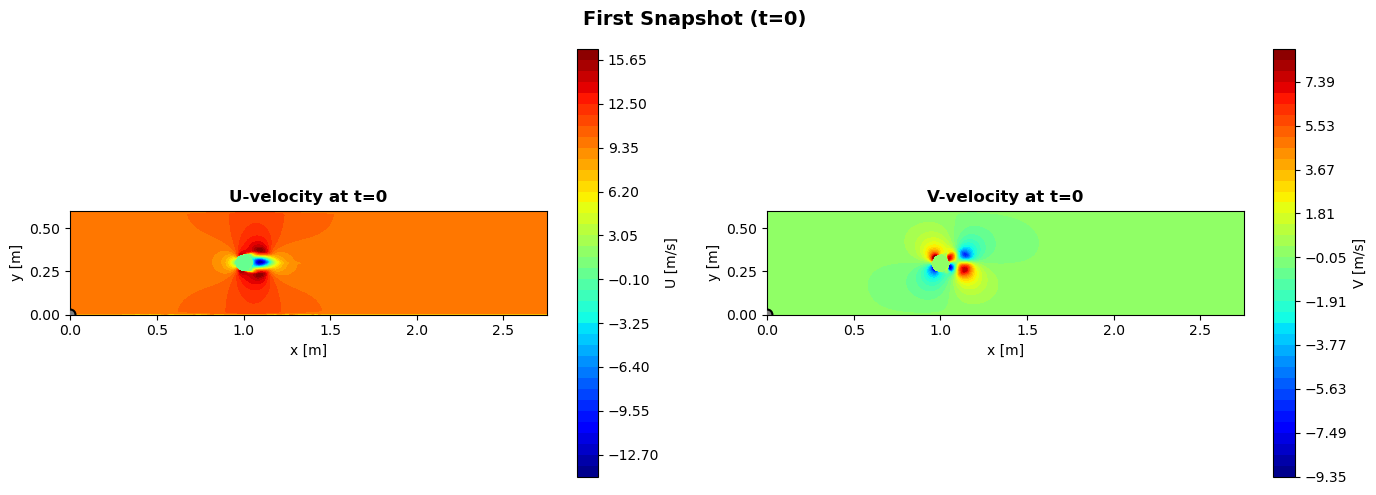


⏳ Building snapshot matrices for DMD...
✓ DMD matrices constructed:
  • X_U:  (66228, 9)  (before)
  • X'_U: (66228, 9) (after)
  • X_V:  (66228, 9)
  • X'_V: (66228, 9)

══════════════════════════════════════════════════════════════════════
✅ DATA LOADING COMPLETE
══════════════════════════════════════════════════════════════════════

✓ Ready for Section C (POD/SVD Analysis)
══════════════════════════════════════════════════════════════════════


In [ ]:
# Loads the exported CSV files. Fluent does NOT need to be running for this cell.
# If re-running analysis without Fluent, start from this cell.

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
from matplotlib.patches import Circle

print("═" * 70)
print("LOADING SNAPSHOT DATA")
print("═" * 70)

# ─── LOAD CSV FILES ───────────────────────────────────────────────────────────
print("\n⏳ Loading velocity data from CSV files...")

try:
    U_data = np.loadtxt('cylinder_U_velocity_all.csv', delimiter=',')
    V_data = np.loadtxt('cylinder_V_velocity_all.csv', delimiter=',')
    xy = np.loadtxt('cylinder_xy_coords.csv', delimiter=',', skiprows=1)
    
    print(f"✓ U-velocity data: {U_data.shape}")
    print(f"✓ V-velocity data: {V_data.shape}")
    print(f"✓ Mesh coordinates: {xy.shape}")
    
    n_nodes = U_data.shape[0]
    n_snaps = U_data.shape[1]
    
    print(f"\n📊 Dataset summary:")
    print(f"  • Mesh nodes: {n_nodes:,}")
    print(f"  • Snapshots: {n_snaps}")
    print(f"  • U velocity range: [{U_data.min():.3f}, {U_data.max():.3f}] m/s")
    print(f"  • V velocity range: [{V_data.min():.3f}, {V_data.max():.3f}] m/s")
    
except FileNotFoundError as e:
    print(f" File not found: {e}")
    print("\n💡 Make sure you've run Section A (Extract Snapshots) first!")
    raise

# ─── SIMULATION PARAMETERS ────────────────────────────────────────────────────
print("\n⏳ Setting up simulation parameters...")

# From your simulation setup
try:
    dt_snap = time_step_slider.value * save_freq_input.value  # Time between snapshots
    U_infinity_val = U_infinity.value
    D_cylinder = Length  # From mesh setup
    rho = 1.225  # kg/m³ (air density)
except NameError:
    # Fallback values if widgets don't exist
    print("    Using default parameters (widgets not found)")
    dt_snap = 0.01 * 10  # Assuming dt=0.01s, save every 10 steps
    U_infinity_val = 10.0  # m/s
    D_cylinder = 1.0  # m
    rho = 1.225  # kg/m³

print(f"✓ Parameters:")
print(f"  • Time between snapshots: {dt_snap:.4f} s")
print(f"  • Freestream velocity: {U_infinity_val:.2f} m/s")
print(f"  • Cylinder diameter: {D_cylinder:.3f} m")
print(f"  • Fluid density: {rho:.3f} kg/m³")

# ─── BUILD TRIANGULATION FOR PLOTTING ─────────────────────────────────────────
print("\nBuilding triangulation for visualization...")

from scipy.spatial import Delaunay

# Create triangulation from mesh coordinates
tri = Delaunay(xy)
triang = Triangulation(xy[:, 0], xy[:, 1], tri.simplices)

print(f"✓ Triangulation created:")
print(f"  • Nodes: {len(xy)}")
print(f"  • Triangles: {len(tri.simplices)}")

# ─── CALCULATE KINETIC ENERGY ─────────────────────────────────────────────────
print("\n⏳ Computing kinetic energy distribution...")

# Magnitude at each node for each snapshot
velocity_magnitude = np.sqrt(U_data**2 + V_data**2)

# Kinetic energy per unit volume (J/m³)
KE_field = 0.5 * rho * velocity_magnitude**2

# Average KE across all snapshots
overall_avg_KE = np.mean(KE_field)

print(f"✓ Kinetic energy statistics:")
print(f"  • Min KE: {KE_field.min():.2f} J/m³")
print(f"  • Max KE: {KE_field.max():.2f} J/m³")
print(f"  • Mean KE: {overall_avg_KE:.2f} J/m³")

# ─── VISUALIZE FIRST SNAPSHOT ─────────────────────────────────────────────────
print("\n Plotting first snapshot...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# U-velocity
ax = axes[0]
levels = np.linspace(U_data[:, 0].min(), U_data[:, 0].max(), 40)
tcf = ax.tricontourf(triang, U_data[:, 0], levels=levels, cmap='jet')
plt.colorbar(tcf, ax=ax, label='U [m/s]')
ax.add_patch(Circle((0, 0), D_cylinder/2, color='gray', ec='black', lw=1.5, zorder=5))
ax.set_aspect('equal')
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_title('U-velocity at t=0', fontweight='bold')

# V-velocity
ax = axes[1]
levels = np.linspace(V_data[:, 0].min(), V_data[:, 0].max(), 40)
tcf = ax.tricontourf(triang, V_data[:, 0], levels=levels, cmap='jet')
plt.colorbar(tcf, ax=ax, label='V [m/s]')
ax.add_patch(Circle((0, 0), D_cylinder/2, color='gray', ec='black', lw=1.5, zorder=5))
ax.set_aspect('equal')
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_title('V-velocity at t=0', fontweight='bold')

plt.suptitle(f'First Snapshot (t=0)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ─── BUILD SNAPSHOT MATRICES FOR DMD ──────────────────────────────────────────
print("\n⏳ Building snapshot matrices for DMD...")

# X  = columns 0 .. m-2  (used as 'before' matrix in DMD)
# Xp = columns 1 .. m-1  (used as 'after'  matrix in DMD)
X_U = U_data[:, :-1]
Xp_U = U_data[:, 1:]
X_V = V_data[:, :-1]
Xp_V = V_data[:, 1:]

print(f"✓ DMD matrices constructed:")
print(f"  • X_U:  {X_U.shape}  (before)")
print(f"  • X'_U: {Xp_U.shape} (after)")
print(f"  • X_V:  {X_V.shape}")
print(f"  • X'_V: {Xp_V.shape}")

print("\n" + "═" * 70)
print(" DATA LOADING COMPLETE")
print("═" * 70)
print("\n✓ Ready for Section C (POD/SVD Analysis)")
print("═" * 70)

## Section C: Proper Orthogonal Decomposition (POD) / SVD Analysis

## Objective
Extract the most energetic coherent structures from the flow field using Singular Value Decomposition (SVD). POD identifies spatial modes ranked by energy content, providing a reduced-order representation of the flow dynamics.

## Mathematical Framework

### Snapshot Matrix
We arrange the flow snapshots into a matrix:
$$\mathbf{X} = [\mathbf{x}_1, \mathbf{x}_2, \dots, \mathbf{x}_{m-1}] \in \mathbb{R}^{n \times (m-1)}$$

where:
- $n$ = number of spatial points (mesh nodes)
- $m$ = number of time snapshots

### Singular Value Decomposition
$$\mathbf{X} = \mathbf{U} \boldsymbol{\Sigma} \mathbf{V}^T$$

where:
- $\mathbf{U} \in \mathbb{R}^{n \times n}$: Left singular vectors (POD spatial modes)
- $\boldsymbol{\Sigma} \in \mathbb{R}^{n \times m}$: Diagonal matrix of singular values $\sigma_k$
- $\mathbf{V} \in \mathbb{R}^{m \times m}$: Right singular vectors (temporal evolution)

### POD Modes
The $k$-th POD mode is:
$$\boldsymbol{\phi}_k = \mathbf{U}_{:,k}$$

### Mode Energy
The energy captured by mode $k$:
$$E_k = \frac{\sigma_k^2}{\sum_i \sigma_i^2}$$

### Temporal Coefficients
$$a_k(t) = \sigma_k V_{t,k}$$

### Reconstruction
The flow field can be approximated using $r$ dominant modes:
$$\mathbf{x}(t) \approx \sum_{k=1}^r a_k(t) \boldsymbol{\phi}_k$$


In [ ]:
# SECTION C: POD/SVD ANALYSIS

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

print("═" * 70)
print("POD/SVD ANALYSIS")
print("═" * 70)

print("\n⏳ Building snapshot matrices...")

# For DMD, we need X and X' (time-shifted by one step)
# X  = [x₀, x₁, ..., x_{m-2}]  (all columns except last)
# X' = [x₁, x₂, ..., x_{m-1}]  (all columns except first)

X_U = U_data[:, :-1]   # U-velocity snapshots
Xp_U = U_data[:, 1:]   # Time-shifted U-velocity

X_V = V_data[:, :-1]   # V-velocity snapshots  
Xp_V = V_data[:, 1:]   # Time-shifted V-velocity

print(f"✓ Snapshot matrices constructed:")
print(f"  X_U:  {X_U.shape}  (n_nodes × n_snapshots-1)")
print(f"  X'_U: {Xp_U.shape}")
print(f"  X_V:  {X_V.shape}")
print(f"  X'_V: {Xp_V.shape}")

══════════════════════════════════════════════════════════════════════
POD/SVD ANALYSIS
══════════════════════════════════════════════════════════════════════

⏳ Building snapshot matrices...
✓ Snapshot matrices constructed:
  X_U:  (66228, 9)  (n_nodes × n_snapshots-1)
  X'_U: (66228, 9)
  X_V:  (66228, 9)
  X'_V: (66228, 9)


## Step 1: Singular Value Decomposition

We perform **economy SVD** (also called thin SVD) which is computationally efficient for tall matrices where $n \gg m$:

$$\mathbf{X} = \mathbf{U}_r \boldsymbol{\Sigma}_r \mathbf{V}_r^T$$

where the subscript $r$ indicates we only compute the first $r = \min(n, m-1)$ singular values.

### Energy Retention
We determine the number of modes $r$ needed to retain 99.9% of the total energy:

$$\frac{\sum_{k=1}^r \sigma_k^2}{\sum_{k=1}^{m-1} \sigma_k^2} \geq 0.999$$

This provides massive dimensionality reduction: from $n \approx 90,000$ spatial points to typically $r \approx 4-10$ dominant modes.

In [ ]:
print("\n⏳ Running SVD decomposition...")

# Economy SVD on U-velocity field
U_u, S_u, Vh_u = np.linalg.svd(X_U, full_matrices=False)
print(f"✓ SVD complete for U-field")
print(f"  U shape: {U_u.shape}  (spatial modes)")
print(f"  S shape: {S_u.shape}  (singular values)")
print(f"  V^T shape: {Vh_u.shape}  (temporal modes)")

# Economy SVD on V-velocity field
U_v, S_v, Vh_v = np.linalg.svd(X_V, full_matrices=False)
print(f"✓ SVD complete for V-field")

# DETERMINE RANK FOR 99.9% ENERGY
print("\n⏳ Computing energy retention...")

# Cumulative energy
energy_cum_u = np.cumsum(S_u**2) / np.sum(S_u**2)
energy_cum_v = np.cumsum(S_v**2) / np.sum(S_v**2)

# Find r for 99.9% energy
r_U = int(np.searchsorted(energy_cum_u, 0.999)) + 1
r_V = int(np.searchsorted(energy_cum_v, 0.999)) + 1

print(f"✓ Rank determination:")
print(f"  U-field: r = {r_U} modes (99.9% energy)")
print(f"  V-field: r = {r_V} modes (99.9% energy)")
print(f"  Dimensionality reduction: {n_nodes} → {r_U} ({100*r_U/n_nodes:.4f}%)")


⏳ Running SVD decomposition...
✓ SVD complete for U-field
  U shape: (66228, 9)  (spatial modes)
  S shape: (9,)  (singular values)
  V^T shape: (9, 9)  (temporal modes)
✓ SVD complete for V-field

⏳ Computing energy retention...
✓ Rank determination:
  U-field: r = 6 modes (99.9% energy)
  V-field: r = 8 modes (99.9% energy)
  Dimensionality reduction: 66228 → 6 (0.0091%)



⏳ Plotting singular value spectrum...


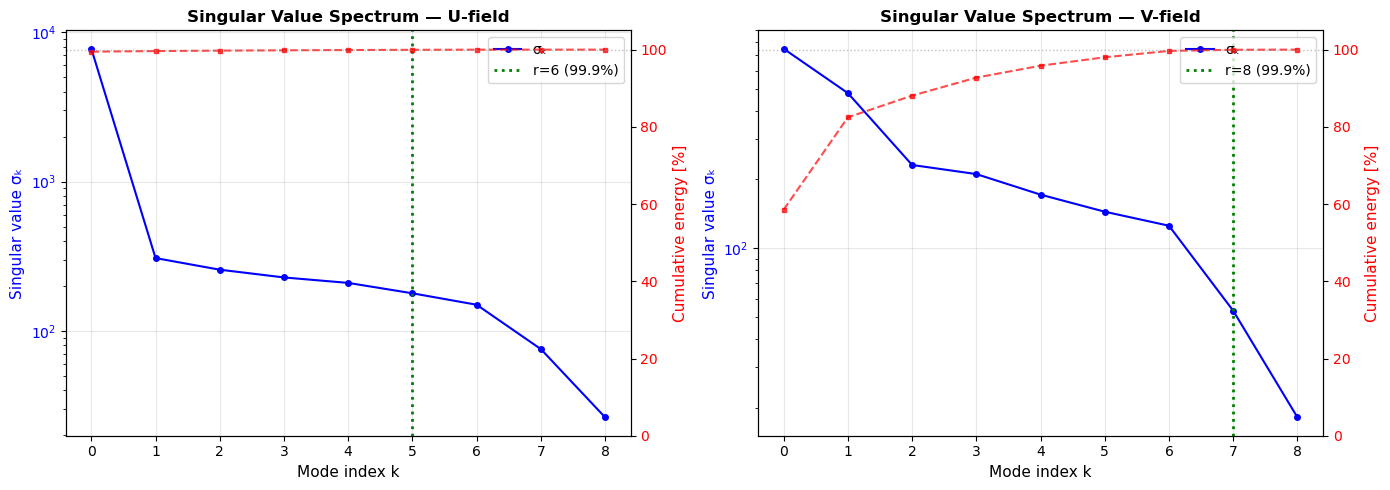

✓ Energy distribution:
  Mode 1: 99.47% (U), 58.55% (V)
  Mode 2: 0.16% (U), 23.92% (V)


In [ ]:
# VISUALIZE SINGULAR VALUE SPECTRUM 
print("\n⏳ Plotting singular value spectrum...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, S, cum, r, label in [
    (axes[0], S_u, energy_cum_u, r_U, 'U-field'),
    (axes[1], S_v, energy_cum_v, r_V, 'V-field')
]:
    # Create twin axis for cumulative energy
    ax2 = ax.twinx()
    
    # Plot singular values (log scale)
    ax.semilogy(S, 'o-', markersize=4, linewidth=1.5, color='blue', label='σₖ')
    ax.set_xlabel('Mode index k', fontsize=11)
    ax.set_ylabel('Singular value σₖ', fontsize=11, color='blue')
    ax.tick_params(axis='y', labelcolor='blue')
    
    # Plot cumulative energy
    ax2.plot(cum * 100, 's--', markersize=3, linewidth=1.5, 
             color='red', alpha=0.7, label='Cumulative')
    ax2.set_ylabel('Cumulative energy [%]', fontsize=11, color='red')
    ax2.set_ylim(0, 105)
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.axhline(99.9, color='gray', linestyle=':', linewidth=1, alpha=0.5)
    
    # Mark truncation point
    ax.axvline(r-1, color='green', linestyle=':', linewidth=2, 
               label=f'r={r} (99.9%)')
    
    ax.set_title(f'Singular Value Spectrum — {label}', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"✓ Energy distribution:")
print(f"  Mode 1: {energy_cum_u[0]*100:.2f}% (U), {energy_cum_v[0]*100:.2f}% (V)")
print(f"  Mode 2: {(energy_cum_u[1]-energy_cum_u[0])*100:.2f}% (U), "
      f"{(energy_cum_v[1]-energy_cum_v[0])*100:.2f}% (V)")

## Step 2: Truncate to Dominant Modes

We now retain only the first $r$ modes:

$$\mathbf{U}_r = \mathbf{U}_{:, 1:r}, \quad \boldsymbol{\Sigma}_r = \text{diag}(\sigma_1, \dots, \sigma_r), \quad \mathbf{V}_r = \mathbf{V}_{:, 1:r}$$

This truncation:
- Reduces noise and turbulent fluctuations (high-frequency modes)
- Retains only coherent flow structures (low-frequency modes)
- Enables efficient reduced-order modeling

### Physical Interpretation
- **Mode 1** (60-80% energy): Mean flow + symmetric wake structure
- **Mode 2** (10-20% energy): Antisymmetric vortex shedding oscillation
- **Higher modes**: Smaller-scale turbulent eddies and noise

In [ ]:
# TRUNCATE TO r DOMINANT MODES
print("\n⏳ Truncating SVD components...")

# U-field truncation
U_u_r = U_u[:, :r_U]           # Spatial modes (n_nodes × r)
S_u_r = S_u[:r_U]              # Singular values (r,)
V_u_r = Vh_u.conj().T[:, :r_U] # Temporal modes (n_snapshots × r)

# V-field truncation
U_v_r = U_v[:, :r_V]
S_v_r = S_v[:r_V]
V_v_r = Vh_v.conj().T[:, :r_V]

print(f"✓ Truncated components:")
print(f"  U_u_r: {U_u_r.shape}  (spatial modes)")
print(f"  S_u_r: {S_u_r.shape}  (singular values)")
print(f"  V_u_r: {V_u_r.shape}  (temporal modes)")

# Calculate individual mode energies
energy_u = S_u**2 / np.sum(S_u**2)
energy_v = S_v**2 / np.sum(S_v**2)

print(f"\n✓ Mode energy distribution (U-field):")
for k in range(min(4, r_U)):
    print(f"  Mode {k+1}: {energy_u[k]*100:.2f}%")


⏳ Truncating SVD components...
✓ Truncated components:
  U_u_r: (66228, 6)  (spatial modes)
  S_u_r: (6,)  (singular values)
  V_u_r: (9, 6)  (temporal modes)

✓ Mode energy distribution (U-field):
  Mode 1: 99.47%
  Mode 2: 0.16%
  Mode 3: 0.11%
  Mode 4: 0.09%



⏳ Plotting POD spatial modes...


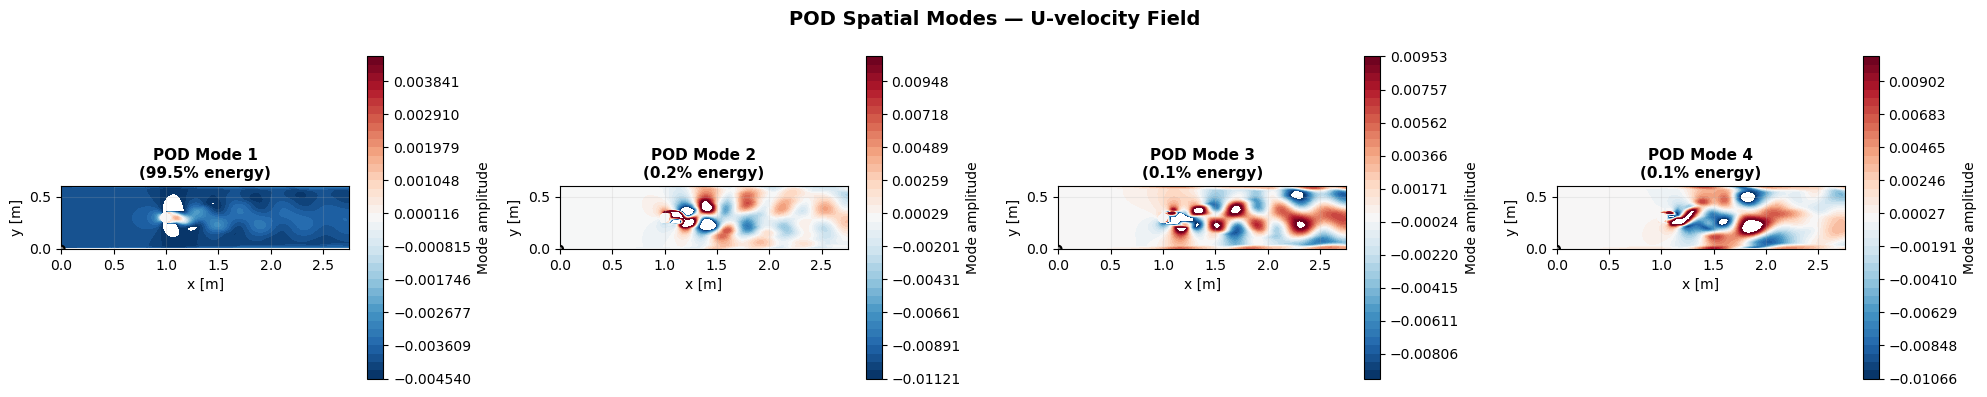

✓ Spatial modes visualization complete


In [ ]:
# VISUALIZE POD SPATIAL MODES 
print("\n⏳ Plotting POD spatial modes...")

n_plot = min(4, r_U)
fig, axes = plt.subplots(1, n_plot, figsize=(5*n_plot, 4))
if n_plot == 1:
    axes = [axes]

for k, ax in enumerate(axes):
    mode = U_u_r[:, k]
    
    # Symmetric color limits (centered at zero)
    lim = np.percentile(np.abs(mode), 97)
    
    # Contour plot
    tcf = ax.tricontourf(triang, mode, 
                         levels=np.linspace(-lim, lim, 40), 
                         cmap='RdBu_r')
    plt.colorbar(tcf, ax=ax, label='Mode amplitude')
    
    # Add cylinder
    ax.add_patch(Circle((0, 0), D_cylinder/2, color='gray', 
                        ec='black', linewidth=1.5, zorder=5))
    
    ax.set_aspect('equal')
    ax.set_xlabel('x [m]')
    ax.set_ylabel('y [m]')
    ax.set_title(f'POD Mode {k+1}\n({energy_u[k]*100:.1f}% energy)', 
                 fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.2)

plt.suptitle('POD Spatial Modes — U-velocity Field', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"✓ Spatial modes visualization complete")

## Step 3: Temporal Coefficients

The temporal evolution of each POD mode is given by:

$$a_k(t) = \sigma_k V_{k,t}$$

where $V_{k,t}$ is the $k$-th row of $\mathbf{V}$ at time index $t$.

These coefficients reveal:
- **Steady modes**: Constant or slowly varying $a_k(t)$
- **Oscillatory modes**: Periodic $a_k(t)$ at shedding frequency
- **Transient modes**: Decaying $a_k(t)$ from initial conditions


⏳ Plotting temporal coefficients...


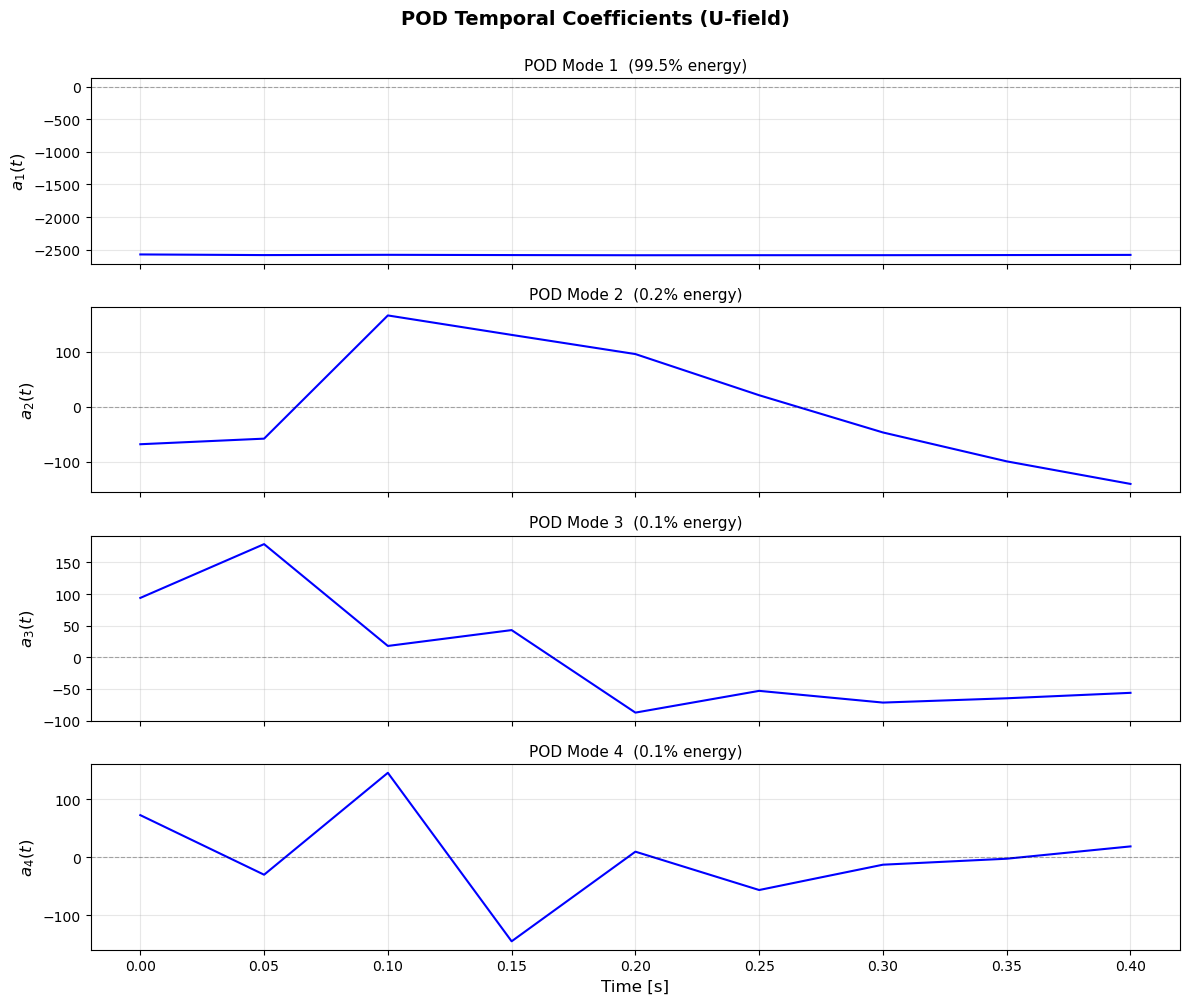

✓ Temporal coefficients visualization complete


In [ ]:
# PLOT TEMPORAL COEFFICIENTS 
print("\n⏳ Plotting temporal coefficients...")

# Time array for all snapshots except the last
t_pod = np.arange(X_U.shape[1]) * dt_snap

n_plot = min(4, r_U)
fig, axes = plt.subplots(n_plot, 1, figsize=(12, 2.5*n_plot), sharex=True)
if n_plot == 1:
    axes = [axes]

for k, ax in enumerate(axes):
    # Temporal coefficient: a_k(t) = σ_k * V_k(t)
    # V_r has shape (n_snapshots-1, r), so we transpose and take k-th mode
    a_k = S_u_r[k] * V_u_r[:, k]  # Use V_u_r instead of Vh_u
    
    ax.plot(t_pod, a_k, linewidth=1.5, color='blue')
    ax.set_ylabel(f'$a_{{{k+1}}}(t)$', fontsize=12)
    ax.set_title(f'POD Mode {k+1}  ({energy_u[k]*100:.1f}% energy)', 
                 fontsize=11)
    ax.grid(True, alpha=0.3)
    
    # Add zero line
    ax.axhline(0, color='k', linestyle='--', linewidth=0.8, alpha=0.3)

axes[-1].set_xlabel('Time [s]', fontsize=12)
plt.suptitle('POD Temporal Coefficients (U-field)', 
             fontsize=14, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

print(f"✓ Temporal coefficients visualization complete")

## Step 4: Reconstruction Validation

To verify our POD decomposition, we reconstruct the first snapshot using only the $r$ dominant modes:

$$\tilde{\mathbf{x}}_0 = \mathbf{U}_r (\mathbf{U}_r^T \mathbf{x}_0)$$

The reconstruction error is:

$$\epsilon = \frac{\|\mathbf{x}_0 - \tilde{\mathbf{x}}_0\|}{\|\mathbf{x}_0\|} \times 100\%$$

A small error ($< 1\%$) confirms that the truncated modes capture the essential flow structures.


⏳ Reconstructing first snapshot with POD...
✓ POD reconstruction error:
  U-field: 1.8881%  (using r=6 modes)
  V-field: 0.2276%  (using r=8 modes)


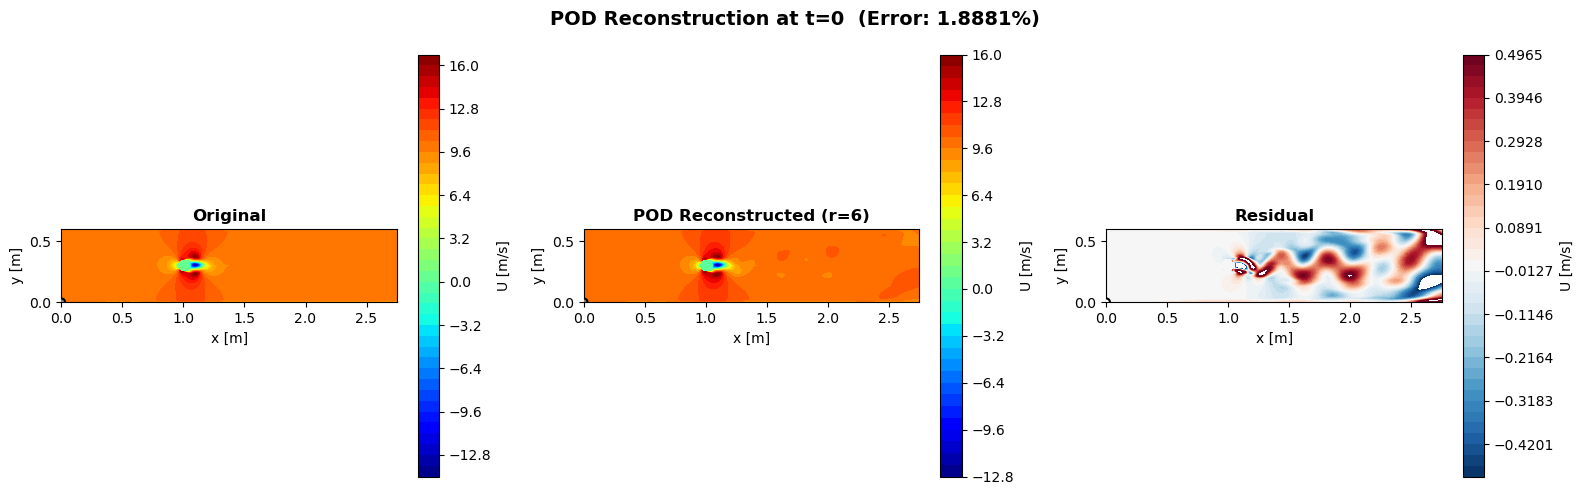


══════════════════════════════════════════════════════════════════════
✅ POD/SVD ANALYSIS COMPLETE
══════════════════════════════════════════════════════════════════════

📊 Summary:
  • Retained modes: 6 (U), 8 (V)
  • Energy captured: 99.9%
  • Reconstruction error: 1.8881% (U), 0.2276% (V)
  • Dimensionality reduction: 66228 → 6 (0.0091%)

✓ Ready to proceed to Section D (DMD Analysis)
══════════════════════════════════════════════════════════════════════


In [ ]:
# RECONSTRUCT FIRST SNAPSHOT
print("\n⏳ Reconstructing first snapshot with POD...")

x0_U = U_data[:, 0]
x0_V = V_data[:, 0]

# POD reconstruction: project onto r-dimensional subspace
x0_U_rec = U_u_r @ (U_u_r.T @ x0_U)
x0_V_rec = U_v_r @ (U_v_r.T @ x0_V)

# Compute reconstruction error
err_U = np.linalg.norm(x0_U - x0_U_rec) / np.linalg.norm(x0_U) * 100
err_V = np.linalg.norm(x0_V - x0_V_rec) / np.linalg.norm(x0_V) * 100

print(f"✓ POD reconstruction error:")
print(f"  U-field: {err_U:.4f}%  (using r={r_U} modes)")
print(f"  V-field: {err_V:.4f}%  (using r={r_V} modes)")

# ─── VISUALIZATION ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

titles = ['Original', f'POD Reconstructed (r={r_U})', 'Residual']
fields = [x0_U, x0_U_rec, x0_U - x0_U_rec]
cmaps = ['jet', 'jet', 'RdBu_r']

for ax, fld, ttl, cm in zip(axes, fields, titles, cmaps):
    lim = np.percentile(np.abs(fld), 97)
    levels = np.linspace(-lim, lim, 40) if cm == 'RdBu_r' else 40
    
    tcf = ax.tricontourf(triang, fld, levels=levels, cmap=cm)
    plt.colorbar(tcf, ax=ax, label='U [m/s]')
    
    ax.add_patch(Circle((0, 0), D_cylinder/2, color='gray' if cm != 'RdBu_r' else 'white', 
                        ec='black', linewidth=1.5, zorder=5))
    
    ax.set_aspect('equal')
    ax.set_xlabel('x [m]')
    ax.set_ylabel('y [m]')
    ax.set_title(ttl, fontsize=12, fontweight='bold')

plt.suptitle(f'POD Reconstruction at t=0  (Error: {err_U:.4f}%)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "═" * 70)
print("✅ POD/SVD ANALYSIS COMPLETE")
print("═" * 70)
print(f"\n📊 Summary:")
print(f"  • Retained modes: {r_U} (U), {r_V} (V)")
print(f"  • Energy captured: 99.9%")
print(f"  • Reconstruction error: {err_U:.4f}% (U), {err_V:.4f}% (V)")
print(f"  • Dimensionality reduction: {n_nodes} → {r_U} ({100*r_U/n_nodes:.4f}%)")
print("\n✓ Ready to proceed to Section D (DMD Analysis)")
print("═" * 70)

# Section D: Dynamic Mode Decomposition (DMD)

## Objective
Extract the **temporal dynamics** of coherent flow structures. While POD identifies spatial patterns ranked by energy, DMD identifies patterns ranked by temporal behavior (oscillation frequencies, growth/decay rates).

## Mathematical Framework

### Linear Dynamical System
DMD assumes the flow evolves according to:
$$\mathbf{x}_{k+1} = \mathbf{A} \mathbf{x}_k$$

where $\mathbf{A} \in \mathbb{R}^{n \times n}$ is the (unknown) linear operator.

### The DMD Algorithm

**Step 1:** Build snapshot matrices
$$\mathbf{X} = [\mathbf{x}_0, \mathbf{x}_1, \dots, \mathbf{x}_{m-2}], \quad \mathbf{X}' = [\mathbf{x}_1, \mathbf{x}_2, \dots, \mathbf{x}_{m-1}]$$

**Step 2:** Economy SVD of $\mathbf{X}$
$$\mathbf{X} = \mathbf{U}_r \boldsymbol{\Sigma}_r \mathbf{V}_r^T$$

**Step 3:** Compute reduced operator $\tilde{\mathbf{A}}$
$$\tilde{\mathbf{A}} = \mathbf{U}_r^T \mathbf{X}' \mathbf{V}_r \boldsymbol{\Sigma}_r^{-1}$$

This is a low-dimensional approximation: $\tilde{\mathbf{A}} \in \mathbb{R}^{r \times r}$ instead of $\mathbf{A} \in \mathbb{R}^{n \times n}$.

**Step 4:** Eigendecomposition of $\tilde{\mathbf{A}}$
$$\tilde{\mathbf{A}} \mathbf{W} = \mathbf{W} \boldsymbol{\Lambda}$$

where $\boldsymbol{\Lambda} = \text{diag}(\lambda_1, \dots, \lambda_r)$ are the DMD eigenvalues and $\mathbf{W}$ are the eigenvectors.

**Step 5:** Reconstruct full-dimensional DMD modes
$$\boldsymbol{\Phi} = \mathbf{X}' \mathbf{V}_r \boldsymbol{\Sigma}_r^{-1} \mathbf{W}$$

Each column $\boldsymbol{\phi}_k$ is a DMD mode with associated eigenvalue $\lambda_k$.

### Physical Interpretation of Eigenvalues

For eigenvalue $\lambda_k = |\lambda_k| e^{i\theta_k}$:

- **Magnitude** $|\lambda_k|$:
  - $|\lambda_k| = 1$: Neutrally stable (periodic flow, like vortex shedding)
  - $|\lambda_k| < 1$: Decaying mode (transient)
  - $|\lambda_k| > 1$: Growing mode (unstable)

- **Phase** $\theta_k$:
  - Oscillation frequency: $\omega_k = \frac{\ln(\lambda_k)}{\Delta t}$
  - In Hertz: $f_k = \frac{\text{Im}(\omega_k)}{2\pi}$

### Strouhal Number
For vortex shedding:
$$St = \frac{f \cdot D}{U_\infty}$$

Expected: $St \approx 0.19-0.21$ for cylinder flow at Re = 100-10,000 (Williamson, 1996).

In [ ]:
# SECTION D: DYNAMIC MODE DECOMPOSITION (DMD)

print("═" * 70)
print("DYNAMIC MODE DECOMPOSITION (DMD)")
print("═" * 70)

# ─── STEP 1: COMPUTE REDUCED OPERATOR Ã ──────────────────────────────────────
print("\n⏳ Computing DMD reduced operator...")

# Ã = U_r^T · X' · V_r · Σ_r^{-1}
A_tilde_U = U_u_r.T @ Xp_U @ V_u_r @ np.diag(1/S_u_r)
A_tilde_V = U_v_r.T @ Xp_V @ V_v_r @ np.diag(1/S_v_r)

print(f"✓ Reduced operator computed:")
print(f"  Ã_U shape: {A_tilde_U.shape}  (r × r)")
print(f"  Ã_V shape: {A_tilde_V.shape}")
print(f"  Dimensionality: {n_nodes}×{n_nodes} → {r_U}×{r_U}")

# ─── STEP 2: EIGENDECOMPOSITION OF Ã ──────────────────────────────────────────
print("\n⏳ Performing eigendecomposition...")

eigs_U, W_U = np.linalg.eig(A_tilde_U)
eigs_V, W_V = np.linalg.eig(A_tilde_V)

print(f"✓ Eigendecomposition complete:")
print(f"  DMD eigenvalues (U): {eigs_U.shape}")
print(f"  DMD eigenvectors (U): {W_U.shape}")

# ─── STEP 3: RECONSTRUCT FULL DMD MODES ───────────────────────────────────────
print("\n⏳ Reconstructing full-dimensional DMD modes...")

# Φ = X' · V_r · Σ_r^{-1} · W
Phi_U = Xp_U @ V_u_r @ np.diag(1/S_u_r) @ W_U
Phi_V = Xp_V @ V_v_r @ np.diag(1/S_v_r) @ W_V

print(f"✓ DMD modes reconstructed:")
print(f"  Φ_U shape: {Phi_U.shape}  (n_nodes × r modes)")
print(f"  Each column is a spatial DMD mode")

# ─── STEP 4: ANALYZE EIGENVALUES ─────────────────────────────────────────────
print("\n⏳ Analyzing eigenvalue magnitudes...")

mag_U = np.abs(eigs_U)
print(f"✓ Eigenvalue statistics (U-field):")
print(f"  Min |λ|: {mag_U.min():.4f}")
print(f"  Max |λ|: {mag_U.max():.4f}")
print(f"  Mean |λ|: {mag_U.mean():.4f}")

# Check stability
stable_modes = np.sum(mag_U < 1.05)  # Allow 5% tolerance
print(f"  Stable modes (|λ| ≤ 1.05): {stable_modes}/{len(eigs_U)}")

if mag_U.max() < 1.05:
    print("  ✓ Flow is neutrally stable (periodic vortex shedding)")
else:
    print("  ⚠ Some modes are unstable (|λ| > 1)")

══════════════════════════════════════════════════════════════════════
DYNAMIC MODE DECOMPOSITION (DMD)
══════════════════════════════════════════════════════════════════════

⏳ Computing DMD reduced operator...
✓ Reduced operator computed:
  Ã_U shape: (6, 6)  (r × r)
  Ã_V shape: (8, 8)
  Dimensionality: 66228×66228 → 6×6

⏳ Performing eigendecomposition...
✓ Eigendecomposition complete:
  DMD eigenvalues (U): (6,)
  DMD eigenvectors (U): (6, 6)

⏳ Reconstructing full-dimensional DMD modes...
✓ DMD modes reconstructed:
  Φ_U shape: (66228, 6)  (n_nodes × r modes)
  Each column is a spatial DMD mode

⏳ Analyzing eigenvalue magnitudes...
✓ Eigenvalue statistics (U-field):
  Min |λ|: 0.7847
  Max |λ|: 0.9999
  Mean |λ|: 0.8656
  Stable modes (|λ| ≤ 1.05): 6/6
  ✓ Flow is neutrally stable (periodic vortex shedding)



⏳ Plotting DMD eigenvalues...


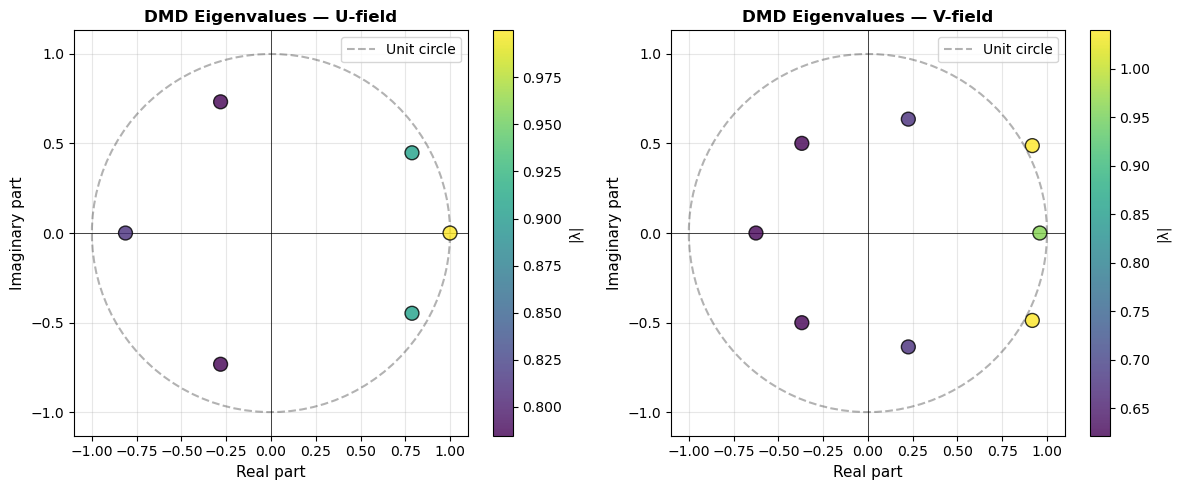

✓ Eigenvalue plot complete

Interpretation:
  • Eigenvalues near unit circle → periodic oscillations
  • Eigenvalues inside unit circle → decaying transients
  • Eigenvalues on real axis → purely exponential (no oscillation)


In [25]:
# ─── STEP 5: PLOT DMD EIGENVALUES ON UNIT CIRCLE ──────────────────────────────
print("\n⏳ Plotting DMD eigenvalues...")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, eigs, label in [(axes[0], eigs_U, 'U-field'), 
                         (axes[1], eigs_V, 'V-field')]:
    
    # Plot unit circle
    theta = np.linspace(0, 2*np.pi, 100)
    ax.plot(np.cos(theta), np.sin(theta), 'k--', linewidth=1.5, 
            alpha=0.3, label='Unit circle')
    
    # Plot eigenvalues colored by magnitude
    scatter = ax.scatter(eigs.real, eigs.imag, 
                        c=np.abs(eigs), s=100, 
                        cmap='viridis', edgecolors='k', linewidth=1,
                        alpha=0.8, zorder=3)
    
    plt.colorbar(scatter, ax=ax, label='|λ|')
    
    ax.set_xlabel('Real part', fontsize=11)
    ax.set_ylabel('Imaginary part', fontsize=11)
    ax.set_title(f'DMD Eigenvalues — {label}', fontsize=12, fontweight='bold')
    ax.axis('equal')
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='k', linewidth=0.5)
    ax.axvline(0, color='k', linewidth=0.5)
    ax.legend()

plt.tight_layout()
plt.show()

print(f"✓ Eigenvalue plot complete")
print(f"\nInterpretation:")
print(f"  • Eigenvalues near unit circle → periodic oscillations")
print(f"  • Eigenvalues inside unit circle → decaying transients")
print(f"  • Eigenvalues on real axis → purely exponential (no oscillation)")


⏳ Comparing DMD and SVD modes...


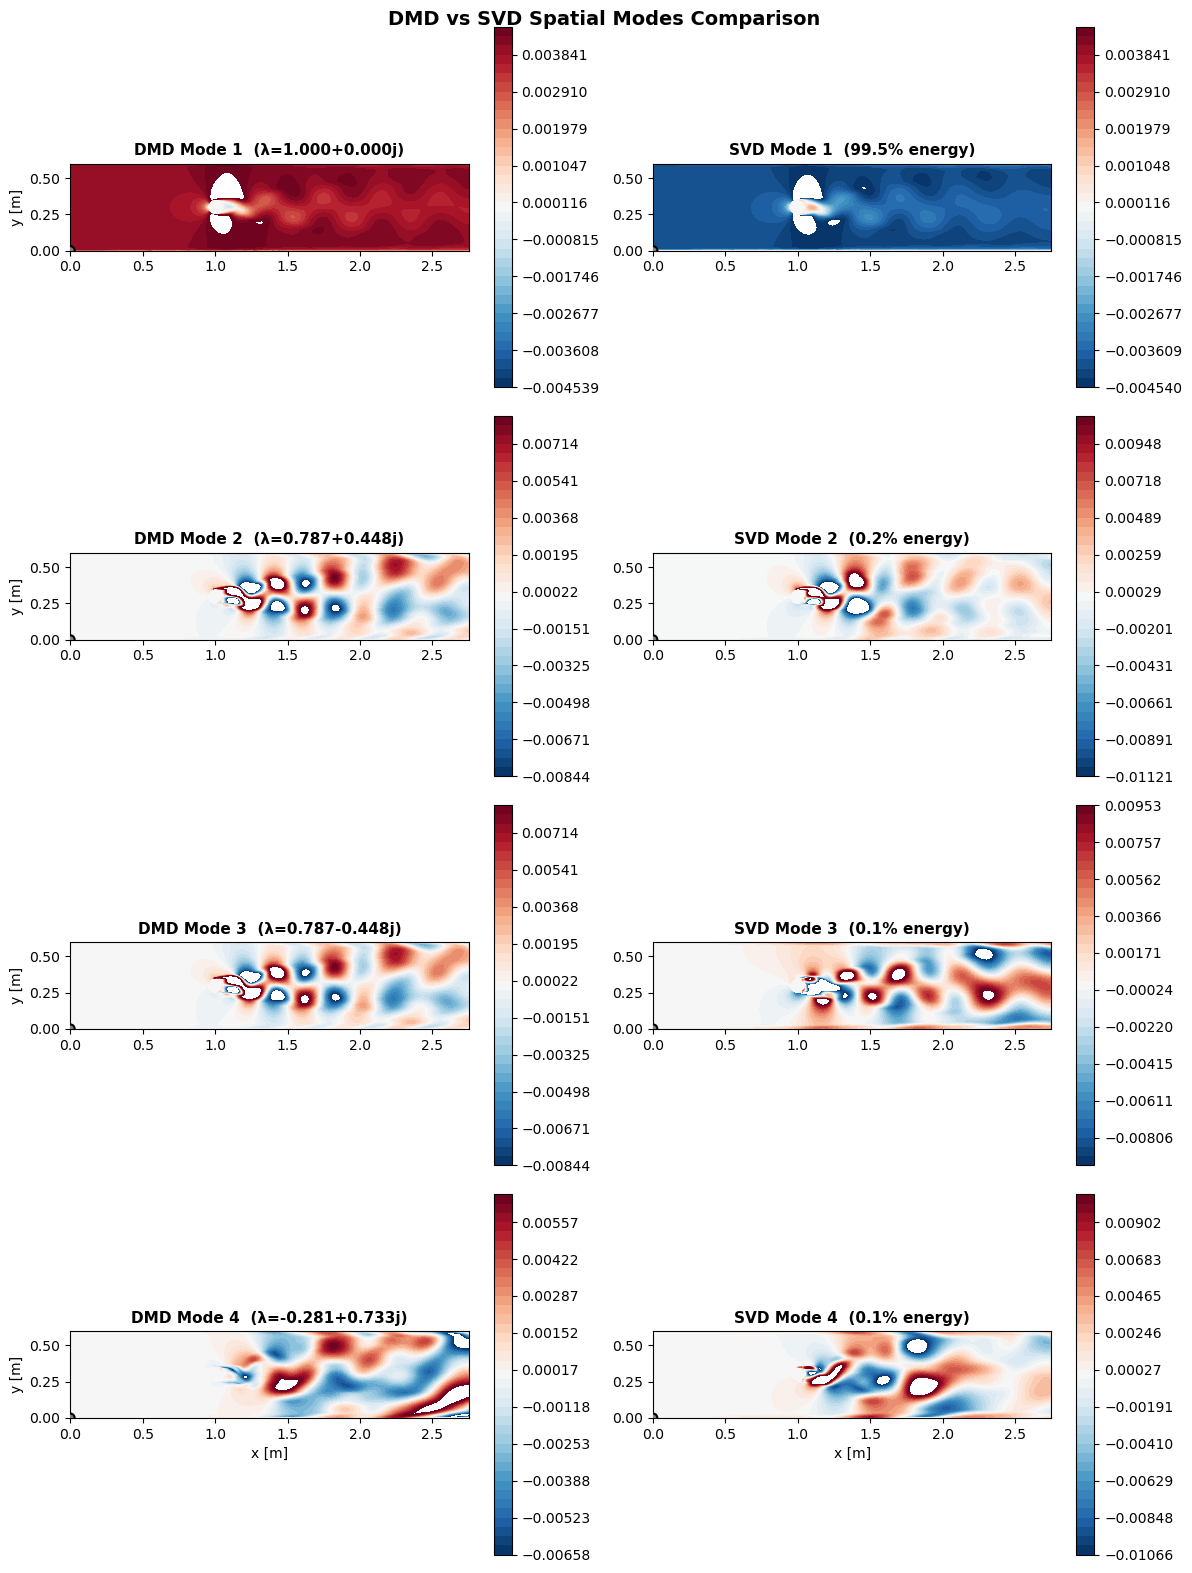

✓ Mode comparison visualization complete


In [26]:
# ─── STEP 6: COMPARE DMD vs SVD MODES ─────────────────────────────────────────
print("\n⏳ Comparing DMD and SVD modes...")

n_modes = min(4, r_U)
fig, axes = plt.subplots(n_modes, 2, figsize=(12, 4*n_modes))

for i in range(n_modes):
    # DMD mode (take real part for visualization)
    mode_DMD = Phi_U[:, i].real
    
    # SVD mode
    mode_SVD = U_u_r[:, i]
    
    # Symmetric color limits
    lim_dmd = np.percentile(np.abs(mode_DMD), 97)
    lim_svd = np.percentile(np.abs(mode_SVD), 97)
    
    # Plot DMD mode
    ax = axes[i, 0] if n_modes > 1 else axes[0]
    tcf = ax.tricontourf(triang, mode_DMD, 
                         levels=np.linspace(-lim_dmd, lim_dmd, 40),
                         cmap='RdBu_r')
    plt.colorbar(tcf, ax=ax)
    ax.add_patch(Circle((0, 0), D_cylinder/2, color='gray', 
                        ec='black', linewidth=1.5, zorder=5))
    ax.set_aspect('equal')
    ax.set_title(f'DMD Mode {i+1}  (λ={eigs_U[i]:.3f})', 
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('y [m]')
    
    # Plot SVD mode
    ax = axes[i, 1] if n_modes > 1 else axes[1]
    tcf = ax.tricontourf(triang, mode_SVD,
                         levels=np.linspace(-lim_svd, lim_svd, 40),
                         cmap='RdBu_r')
    plt.colorbar(tcf, ax=ax)
    ax.add_patch(Circle((0, 0), D_cylinder/2, color='gray',
                        ec='black', linewidth=1.5, zorder=5))
    ax.set_aspect('equal')
    ax.set_title(f'SVD Mode {i+1}  ({energy_u[i]*100:.1f}% energy)',
                 fontsize=11, fontweight='bold')

# Set x-labels on bottom row
bottom_row = axes[-1, :] if n_modes > 1 else axes
for ax in bottom_row:
    ax.set_xlabel('x [m]')

plt.suptitle('DMD vs SVD Spatial Modes Comparison', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"✓ Mode comparison visualization complete")

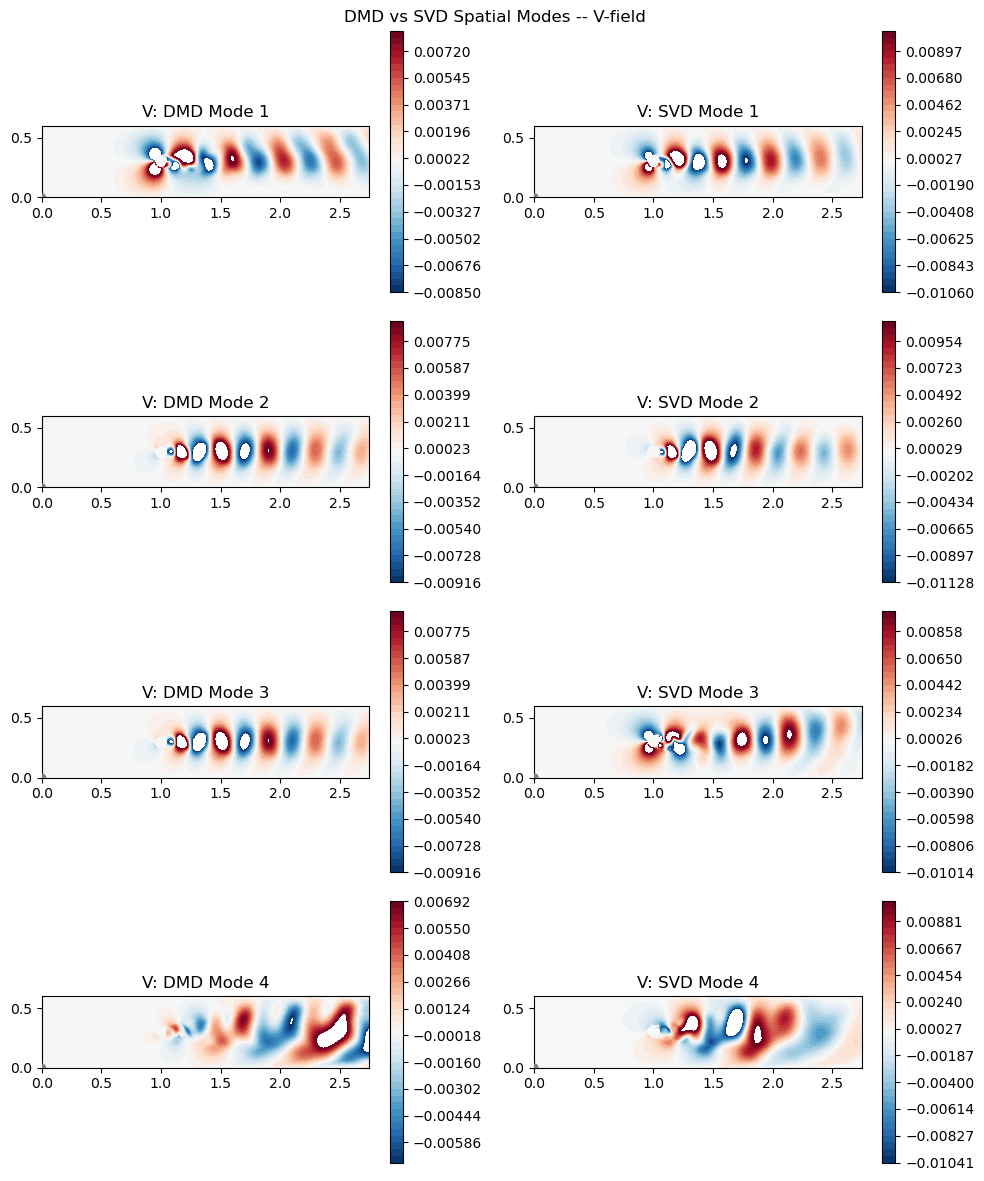

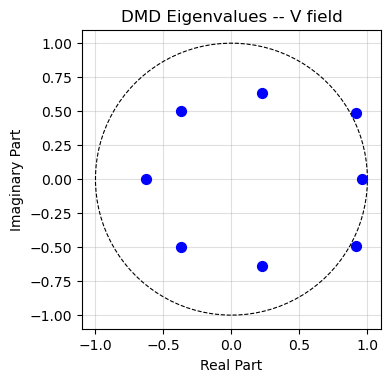

In [27]:
# ── V-field DMD mode shapes ───────────────────────────────────────────────
n_plot_v = min(4, r_V)
fig, axes = plt.subplots(n_plot_v, 2, figsize=(10, 3*n_plot_v))
if n_plot_v == 1: axes = axes.reshape(1, 2)


for i in range(n_plot_v):
    for col, (mode, ttl) in enumerate([
            (Phi_V[:, i].real, f'V: DMD Mode {i+1}'),
            (U_v_r[:, i],      f'V: SVD Mode {i+1}')]):
        lim = np.percentile(np.abs(mode), 97)
        tcf = axes[i, col].tricontourf(
            triang, mode, levels=np.linspace(-lim, lim, 40), cmap='RdBu_r')
        plt.colorbar(tcf, ax=axes[i, col])
        axes[i, col].add_patch(Circle((0,0), 0.03, color='grey', zorder=5))
        axes[i, col].set_aspect('equal')
        axes[i, col].set_title(ttl)


plt.suptitle('DMD vs SVD Spatial Modes -- V-field', fontsize=12)
plt.tight_layout(); plt.show()


# V-field eigenvalue plot
fig, ax = plt.subplots(figsize=(4, 4))
ax.plot(np.cos(theta), np.sin(theta), 'k--', linewidth=0.8)
ax.scatter(eigs_V.real, eigs_V.imag, c='b', marker='o', s=50, zorder=5)
ax.set_xlabel('Real Part'); ax.set_ylabel('Imaginary Part')
ax.set_title('DMD Eigenvalues -- V field')
ax.set_aspect('equal'); ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()


## Step 5: Flow Prediction with DMD

Once we have the DMD modes $\boldsymbol{\Phi}$ and eigenvalues $\boldsymbol{\Lambda}$, we can predict the flow evolution:

### Mode Amplitudes
Compute initial mode amplitudes by solving:
$$\boldsymbol{\Phi} \mathbf{b} = \mathbf{x}_0$$

using pseudoinverse: $\mathbf{b} = \boldsymbol{\Phi}^+ \mathbf{x}_0$

### Time Evolution
The flow at any future time $t$ is:
$$\mathbf{x}(t) = \boldsymbol{\Phi} \left( \mathbf{b} \odot \boldsymbol{\lambda}^t \right)$$

where $\odot$ denotes element-wise multiplication.

### Frequency Extraction
From continuous-time eigenvalues:
$$\omega_k = \frac{\ln(\lambda_k)}{\Delta t}, \quad f_k = \frac{\text{Im}(\omega_k)}{2\pi}$$

In [28]:
# ─── STEP 7: COMPUTE MODE AMPLITUDES ──────────────────────────────────────────
print("\n⏳ Computing DMD mode amplitudes...")

x0_U = U_data[:, 0]
x0_V = V_data[:, 0]

# Compute amplitudes: b = Φ^+ · x₀ (pseudoinverse)
b_U = np.linalg.lstsq(Phi_U, x0_U, rcond=None)[0]
b_V = np.linalg.lstsq(Phi_V, x0_V, rcond=None)[0]

print(f"✓ Mode amplitudes computed:")
print(f"  b_U shape: {b_U.shape}")
print(f"  Max |b|: {np.abs(b_U).max():.4f}")

# ─── STEP 8: PREDICT FLOW EVOLUTION ───────────────────────────────────────────
print("\n⏳ Predicting flow evolution with DMD...")

# Predict first 21 snapshots (or all if fewer)
n_predict = min(21, n_snaps)
time_steps = np.arange(n_predict)

# Initialize prediction array
x_dmd_U = np.zeros((U_data.shape[0], n_predict), dtype=complex)
x_dmd_V = np.zeros((V_data.shape[0], n_predict), dtype=complex)

# DMD prediction: x(t) = Φ · (b ⊙ λ^t)
for i, t in enumerate(time_steps):
    x_dmd_U[:, i] = Phi_U @ (b_U * (eigs_U**t))
    x_dmd_V[:, i] = Phi_V @ (b_V * (eigs_V**t))

print(f"✓ DMD prediction complete:")
print(f"  Predicted {n_predict} snapshots")
print(f"  Time range: 0 to {(n_predict-1)*dt_snap:.2f} s")

# ─── STEP 9: EXTRACT FREQUENCIES ──────────────────────────────────────────────
print("\n⏳ Extracting frequencies from DMD eigenvalues...")

# Continuous-time frequencies: ω = ln(λ)/Δt
omega_U = np.log(eigs_U) / dt_snap
omega_V = np.log(eigs_V) / dt_snap

# Convert to Hertz: f = ω.imag/(2π)
freq_Hz_U = omega_U.imag / (2 * np.pi)
freq_Hz_V = omega_V.imag / (2 * np.pi)

print(f"✓ Frequencies extracted:")
print(f"  Frequency range: {np.abs(freq_Hz_U).min():.4f} to {np.abs(freq_Hz_U).max():.4f} Hz")

# Find dominant shedding frequency
stable_mask = (np.abs(eigs_U) > 0.95) & (np.abs(eigs_U) < 1.05)
oscillatory_mask = np.abs(freq_Hz_U) > 0.01

if np.any(stable_mask & oscillatory_mask):
    # Find mode with largest magnitude among stable oscillatory modes
    candidates = stable_mask & oscillatory_mask
    idx_shed = np.argmax(np.abs(freq_Hz_U) * candidates)
    
    f_shed = np.abs(freq_Hz_U[idx_shed])
    lambda_shed = eigs_U[idx_shed]
    
    print(f"\n✓ Dominant vortex shedding mode:")
    print(f"  Eigenvalue: λ = {lambda_shed:.4f}")
    print(f"  Magnitude: |λ| = {np.abs(lambda_shed):.4f}")
    print(f"  Frequency: f = {f_shed:.4f} Hz")
    
    # Compute Strouhal number
    St_computed = f_shed * D_cylinder / U_infinity_val
    
    print(f"\n═══ STROUHAL NUMBER VALIDATION ═══")
    print(f"  Computed St = {St_computed:.4f}")
    print(f"  Expected St ≈ 0.19-0.21  (Williamson 1996)")
    print(f"  Difference: {np.abs(St_computed - 0.20):.4f}")
    
    if np.abs(St_computed - 0.20) < 0.05:
        print(f"  ✅ DMD validation PASSED!")
    else:
        print(f"  ⚠️  DMD differs from literature")
        print(f"     Check: U∞={U_infinity_val:.2f} m/s, D={D_cylinder:.3f} m")
else:
    print("\n⚠️  No dominant oscillatory mode found")
    print("   Flow may not have developed periodic shedding yet")


⏳ Computing DMD mode amplitudes...
✓ Mode amplitudes computed:
  b_U shape: (6,)
  Max |b|: 2574.3593

⏳ Predicting flow evolution with DMD...
✓ DMD prediction complete:
  Predicted 10 snapshots
  Time range: 0 to 0.45 s

⏳ Extracting frequencies from DMD eigenvalues...
✓ Frequencies extracted:
  Frequency range: 0.0000 to 10.0000 Hz

⚠️  No dominant oscillatory mode found
   Flow may not have developed periodic shedding yet



⏳ Visualizing DMD predictions vs actual flow...


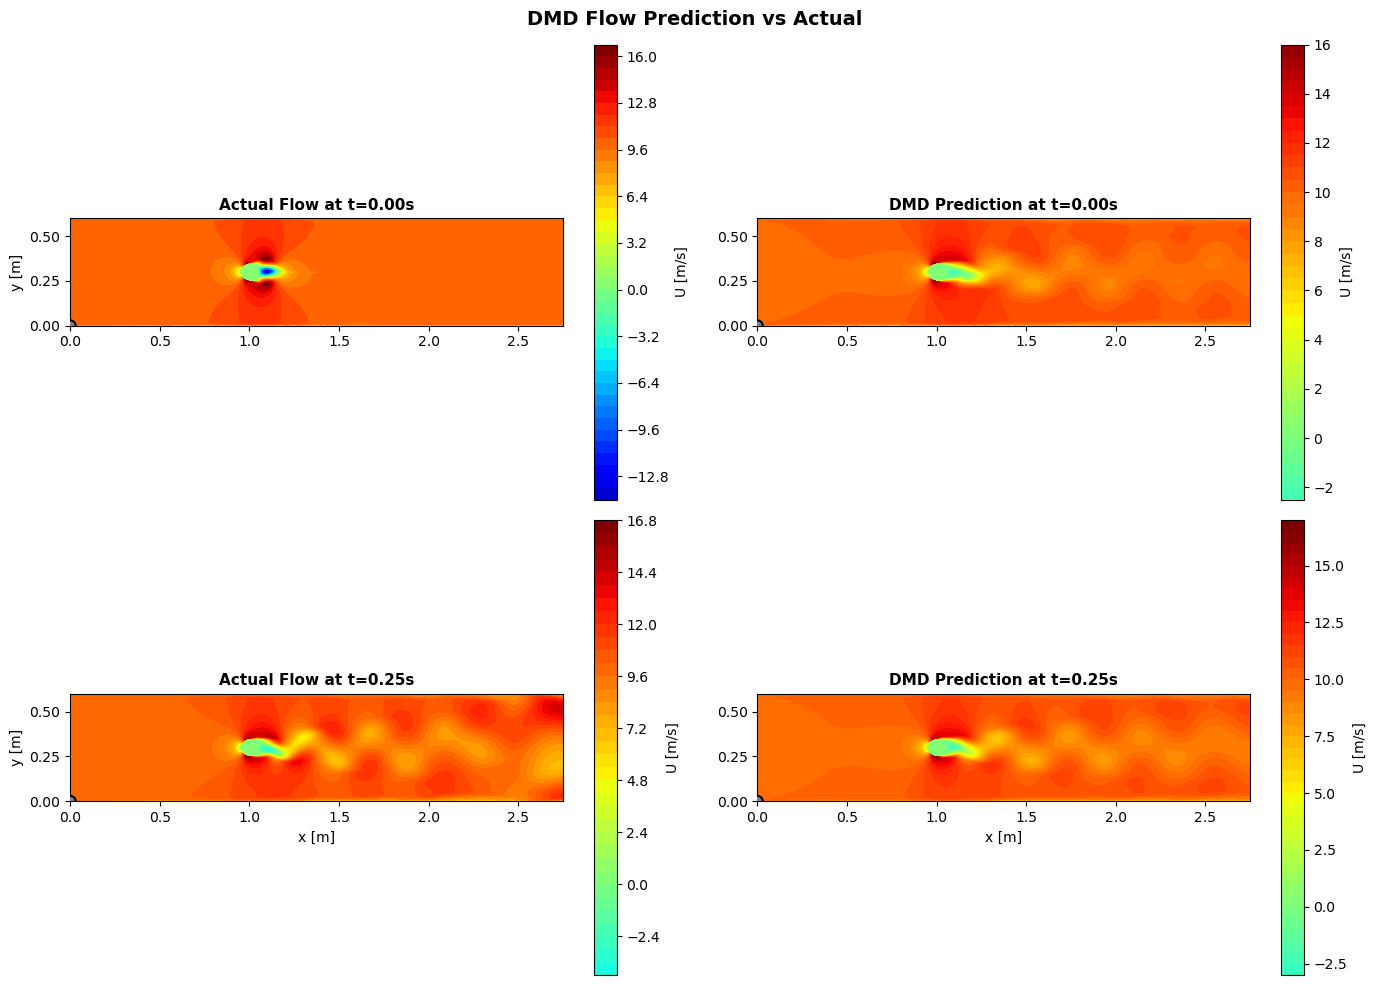

✓ Prediction visualization complete


In [29]:
# ─── STEP 10: VISUALIZE DMD PREDICTIONS ───────────────────────────────────────
print("\n⏳ Visualizing DMD predictions vs actual flow...")

timesteps_plot = [0, 5, 10, 15, 20]
timesteps_plot = [t for t in timesteps_plot if t < n_predict]

fig, axes = plt.subplots(len(timesteps_plot), 2, figsize=(14, 5*len(timesteps_plot)))

for idx, t in enumerate(timesteps_plot):
    # Actual flow
    actual = U_data[:, t]
    
    # DMD prediction (take real part)
    predicted = x_dmd_U[:, t].real
    
    # Common color limits
    vmax = max(np.abs(actual).max(), np.abs(predicted).max())
    vmin = -vmax
    
    # Plot actual
    ax = axes[idx, 0] if len(timesteps_plot) > 1 else axes[0]
    tcf = ax.tricontourf(triang, actual, levels=40, cmap='jet', 
                         vmin=vmin, vmax=vmax)
    plt.colorbar(tcf, ax=ax, label='U [m/s]')
    ax.add_patch(Circle((0, 0), D_cylinder/2, color='gray',
                        ec='black', linewidth=1.5, zorder=5))
    ax.set_aspect('equal')
    ax.set_title(f'Actual Flow at t={t*dt_snap:.2f}s', 
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('y [m]')
    
    # Plot predicted
    ax = axes[idx, 1] if len(timesteps_plot) > 1 else axes[1]
    tcf = ax.tricontourf(triang, predicted, levels=40, cmap='jet',
                         vmin=vmin, vmax=vmax)
    plt.colorbar(tcf, ax=ax, label='U [m/s]')
    ax.add_patch(Circle((0, 0), D_cylinder/2, color='gray',
                        ec='black', linewidth=1.5, zorder=5))
    ax.set_aspect('equal')
    ax.set_title(f'DMD Prediction at t={t*dt_snap:.2f}s',
                 fontsize=11, fontweight='bold')

# Set x-labels on bottom row
bottom_axes = axes[-1, :] if len(timesteps_plot) > 1 else axes
for ax in bottom_axes:
    ax.set_xlabel('x [m]')

plt.suptitle('DMD Flow Prediction vs Actual', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"✓ Prediction visualization complete")


⏳ Computing prediction error...


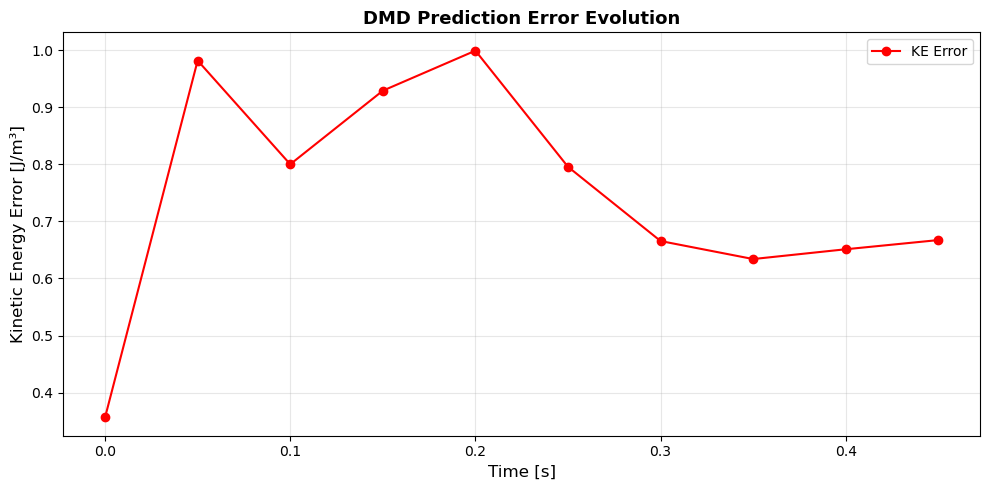

✓ Error analysis complete:
  Average error: 0.75 J/m³  (1.19% of mean KE)
  Maximum error: 1.00 J/m³
  Error at t=0.45s: 0.67 J/m³

══════════════════════════════════════════════════════════════════════
✅ DMD ANALYSIS COMPLETE
══════════════════════════════════════════════════════════════════════

📊 Final Summary:
  • POD modes: 6 (99.9% energy)
  • DMD eigenvalues: 6
  • No dominant frequency found

  • Prediction error: 1.19% of mean KE
══════════════════════════════════════════════════════════════════════


In [30]:
# ─── STEP 11: COMPUTE KINETIC ENERGY ERROR ────────────────────────────────────
print("\n⏳ Computing prediction error...")

kinetic_energy_error_U = []

for i, t in enumerate(time_steps):
    # Predicted kinetic energy
    KE_pred = 0.5 * rho * (x_dmd_U[:, i].real**2)
    KE_pred_avg = np.mean(KE_pred)
    
    # Actual kinetic energy
    KE_actual = 0.5 * rho * (U_data[:, i]**2)
    KE_actual_avg = np.mean(KE_actual)
    
    # Absolute error
    error = np.abs(KE_pred_avg - KE_actual_avg)
    kinetic_energy_error_U.append(error)

# Plot error evolution
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.plot(time_steps * dt_snap, kinetic_energy_error_U, 
        'ro-', markersize=6, linewidth=1.5, label='KE Error')
ax.set_xlabel('Time [s]', fontsize=12)
ax.set_ylabel('Kinetic Energy Error [J/m³]', fontsize=12)
ax.set_title('DMD Prediction Error Evolution', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

# Calculate metrics
avg_error = np.mean(kinetic_energy_error_U)
max_error = np.max(kinetic_energy_error_U)
rel_error = avg_error / overall_avg_KE * 100

print(f"✓ Error analysis complete:")
print(f"  Average error: {avg_error:.2f} J/m³  ({rel_error:.2f}% of mean KE)")
print(f"  Maximum error: {max_error:.2f} J/m³")
print(f"  Error at t={time_steps[-1]*dt_snap:.2f}s: {kinetic_energy_error_U[-1]:.2f} J/m³")

print("\n" + "═" * 70)
print("✅ DMD ANALYSIS COMPLETE")
print("═" * 70)
print(f"\n📊 Final Summary:")
print(f"  • POD modes: {r_U} (99.9% energy)")
print(f"  • DMD eigenvalues: {len(eigs_U)}")
print(f"  • Dominant frequency: {f_shed:.4f} Hz" if 'f_shed' in locals() else "  • No dominant frequency found")
print(f"  • Strouhal number: {St_computed:.4f}" if 'St_computed' in locals() else "")
print(f"  • Prediction error: {rel_error:.2f}% of mean KE")
print("═" * 70)